# **1. Import Libraries**

In [1]:
pip install dython

In [2]:
import pandas as pd
import numpy as np
import io

import os
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from dython.nominal import associations
from scipy.stats import ttest_ind, pearsonr, f_oneway, probplot, shapiro
from scipy import stats

from sklearn.model_selection import RandomizedSearchCV, train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectFromModel, mutual_info_regression
from xgboost import XGBRegressor
from sklearn.model_selection import learning_curve

import shap
import joblib

In [3]:
# Buat folder fonts
!mkdir -p /root/.fonts/

# Unduh Poppins Regular & Bold langsung ke folder
!wget -q https://github.com/google/fonts/raw/main/ofl/poppins/Poppins-Regular.ttf -P /root/.fonts/
!wget -q https://github.com/google/fonts/raw/main/ofl/poppins/Poppins-Bold.ttf -P /root/.fonts/

# Refresh font cache
!fc-cache -fv

# Tambahkan ke font manager matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/root/.fonts/Poppins-Regular.ttf')
fm.fontManager.addfont('/root/.fonts/Poppins-Bold.ttf')

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: caching, new cache contents: 2 fonts, 0 dirs
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache directory
fc-cache: succeeded


# **2. Load Data**

In [4]:
# Memuat dataset
df1 = pd.read_csv('student-mat.csv', sep=';')
df2 = pd.read_csv('student-por.csv', sep=';')
display(df1.head())
display(df2.head())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [5]:
# Menggabungkan dataset
df1['course'] = 'mat'
df2['course'] = 'por'
df = pd.concat([df1, df2], ignore_index=True)
print(df.shape)
display(df.head())

(1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


In [6]:
# Menampilkan informasi umum
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [7]:
# Mengelompokkan kolom-kolom
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Kolom numerik:", num_cols)
print("Kolom kategorikal:", cat_cols)

Kolom numerik: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
Kolom kategorikal: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'course']


In [8]:
# Menampilkan statistik deskriptif
display(df[cat_cols].describe())
display(df[num_cols].describe())

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,course
count,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044,1044
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no,por
freq,772,591,759,738,923,399,584,430,728,925,640,824,528,835,955,827,673,649


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# **3. Exploratory Data Analysis**

### Pengaturan

In [9]:
# Menginisiasi palet warna
palette = ['#A1A1A1', '#454545', '#FF6000', '#FFA559', '#FFE6C7']
sns.set_palette(palette)

# Set default font ke Poppins
plt.rcParams['font.family'] = 'Poppins'

# Warna & style axis
plt.rcParams['axes.edgecolor'] = '#555555'
plt.rcParams['xtick.color'] = '#555555'
plt.rcParams['ytick.color'] = '#555555'
plt.rcParams['axes.labelcolor'] = '#555555'
plt.rcParams['axes.titlecolor'] = '#555555'
plt.rcParams['legend.edgecolor'] = '#555555'
plt.rcParams['legend.labelcolor'] = '#555555'
plt.rcParams['text.color'] = '#555555'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '0.8'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['axes.axisbelow'] = True

In [10]:
def ttest_with_effect_size(df, group_col, group1, group2, features, alpha=0.05):
    results = []

    for feature in features:
        group1_scores = df[df[group_col] == group1][feature]
        group2_scores = df[df[group_col] == group2][feature]

        t_stat, p_value = ttest_ind(group1_scores, group2_scores, equal_var=False)

        mean1 = group1_scores.mean()
        mean2 = group2_scores.mean()
        mean_diff = mean2 - mean1

        n1 = len(group1_scores)
        n2 = len(group2_scores)
        s1 = group1_scores.std(ddof=1)
        s2 = group2_scores.std(ddof=1)
        pooled_sd = np.sqrt(((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2))
        cohen_d = mean_diff / pooled_sd

        abs_d = abs(cohen_d)
        if abs_d < 0.2:
            strength = "sangat kecil"
        elif abs_d < 0.5:
            strength = "kecil"
        elif abs_d < 0.8:
            strength = "sedang"
        else:
            strength = "besar"

        signif = "Signifikan" if p_value < alpha else "Tidak signifikan"

        results.append({
            "Fitur": feature,
            f"Rata-rata {group1}": mean1,
            f"Rata-rata {group2}": mean2,
            "Selisih rata-rata": mean_diff,
            "p-value": p_value,
            "Kesimpulan": signif,
            "Effect size (Cohen's d)": cohen_d,
            "Interpretasi Effect Size": strength
        })

    results_df = pd.DataFrame(results)
    return results_df

In [11]:
def pearson_corr_with_strength(df, x_col, features, alpha=0.05):
    results = []

    for feature in features:
        corr, p_value = pearsonr(df[x_col], df[feature])
        abs_corr = abs(corr)

        if abs_corr < 0.1:
            strength = "sangat lemah"
        elif abs_corr < 0.3:
            strength = "lemah"
        elif abs_corr < 0.5:
            strength = "sedang"
        elif abs_corr < 0.7:
            strength = "kuat"
        else:
            strength = "sangat kuat"

        signif = "Signifikan" if p_value < alpha else "Tidak signifikan"

        results.append({
            "Fitur": feature,
            "Koefisien Korelasi (r)": corr,
            "p-value": p_value,
            "Kesimpulan": signif,
            "Kekuatan Korelasi": strength if p_value < alpha else "-"
        })

    return pd.DataFrame(results)

In [12]:
def anova_with_eta_squared(df, group_col, features, alpha=0.05):
    """
    ANOVA untuk banyak fitur.
    Hasil: F-statistic, p-value, eta squared, dan interpretasi effect size.
    """
    results = []
    groups = df[group_col].unique()

    for feature in features:
        data_per_group = [df[df[group_col] == g][feature] for g in groups]

        f_stat, p_value = f_oneway(*data_per_group)

        grand_mean = df[feature].mean()
        ss_between = sum(len(group) * (group.mean() - grand_mean) ** 2 for group in data_per_group)
        ss_total = sum((df[feature] - grand_mean) ** 2)
        eta_sq = ss_between / ss_total if ss_total != 0 else 0

        if eta_sq < 0.01:
            strength = "sangat kecil"
        elif eta_sq < 0.06:
            strength = "kecil"
        elif eta_sq < 0.14:
            strength = "sedang"
        else:
            strength = "besar"

        signif = "Signifikan" if p_value < alpha else "Tidak signifikan"

        results.append({
            "Fitur": feature,
            "F-statistic": f_stat,
            "p-value": p_value,
            "Kesimpulan": signif,
            "Eta Squared": eta_sq,
            "Kekuatan Efek": strength if p_value < alpha else "-"
        })

    return pd.DataFrame(results)

### Analisis Univariat & Multivariat

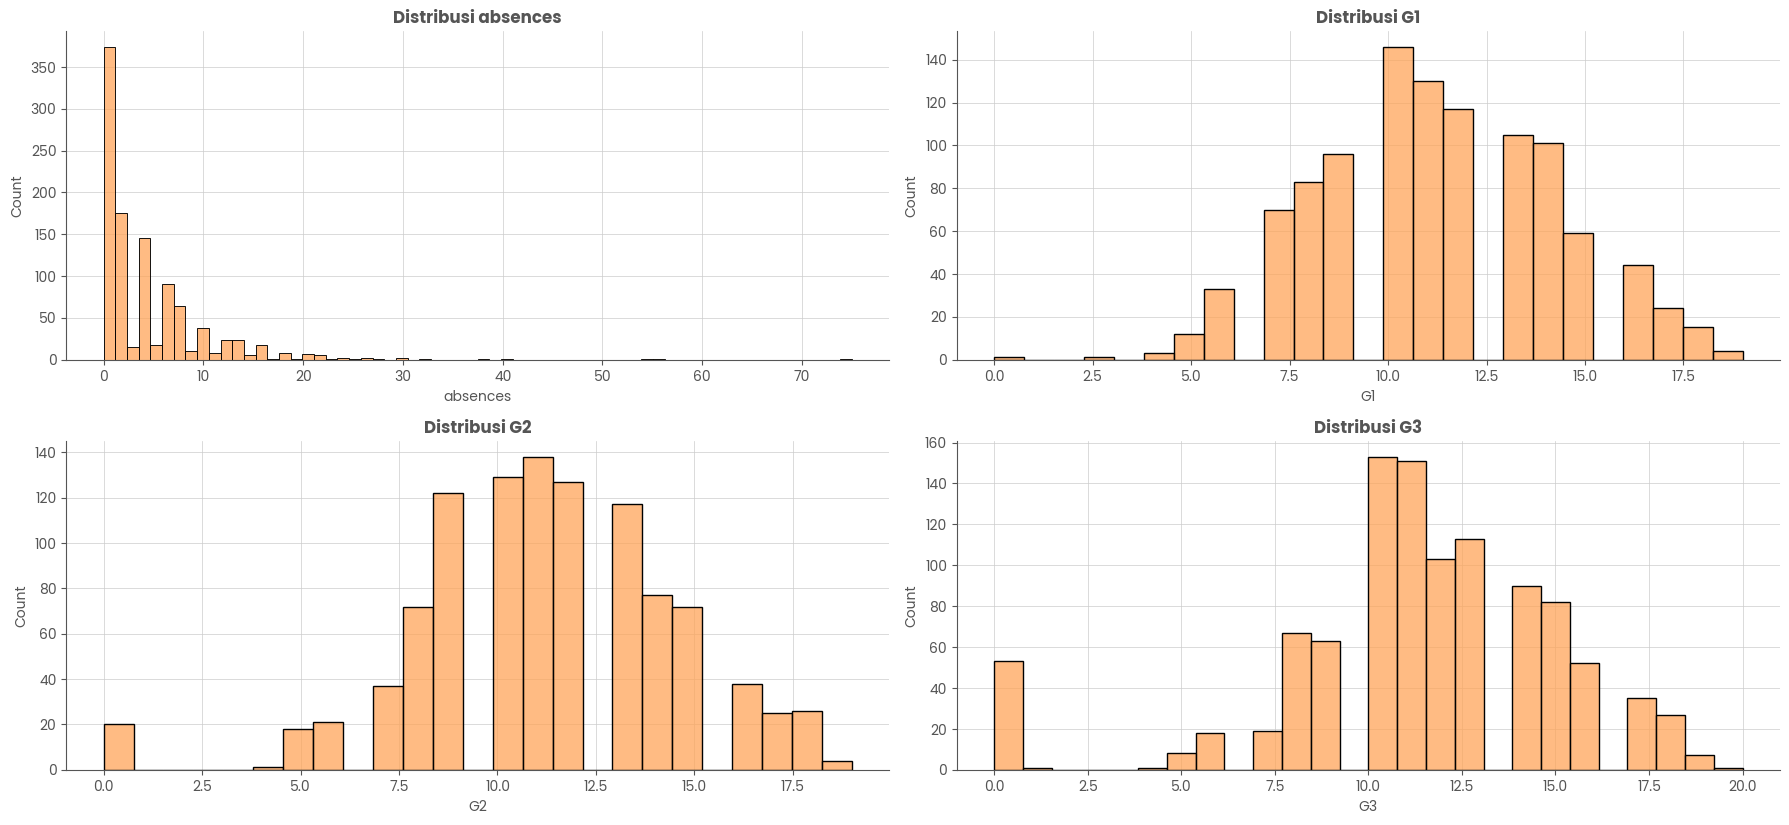

In [ ]:
# Menampilkan visualisasi histogram
hist_cols = ['absences', 'G1', 'G2', 'G3']
n_cols = 2
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(hist_cols):
    sns.histplot(data=df, x=col, ax=axes[i], color=palette[3])
    axes[i].set_title(f'Distribusi {col}', fontweight='bold')

for j in range(len(hist_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

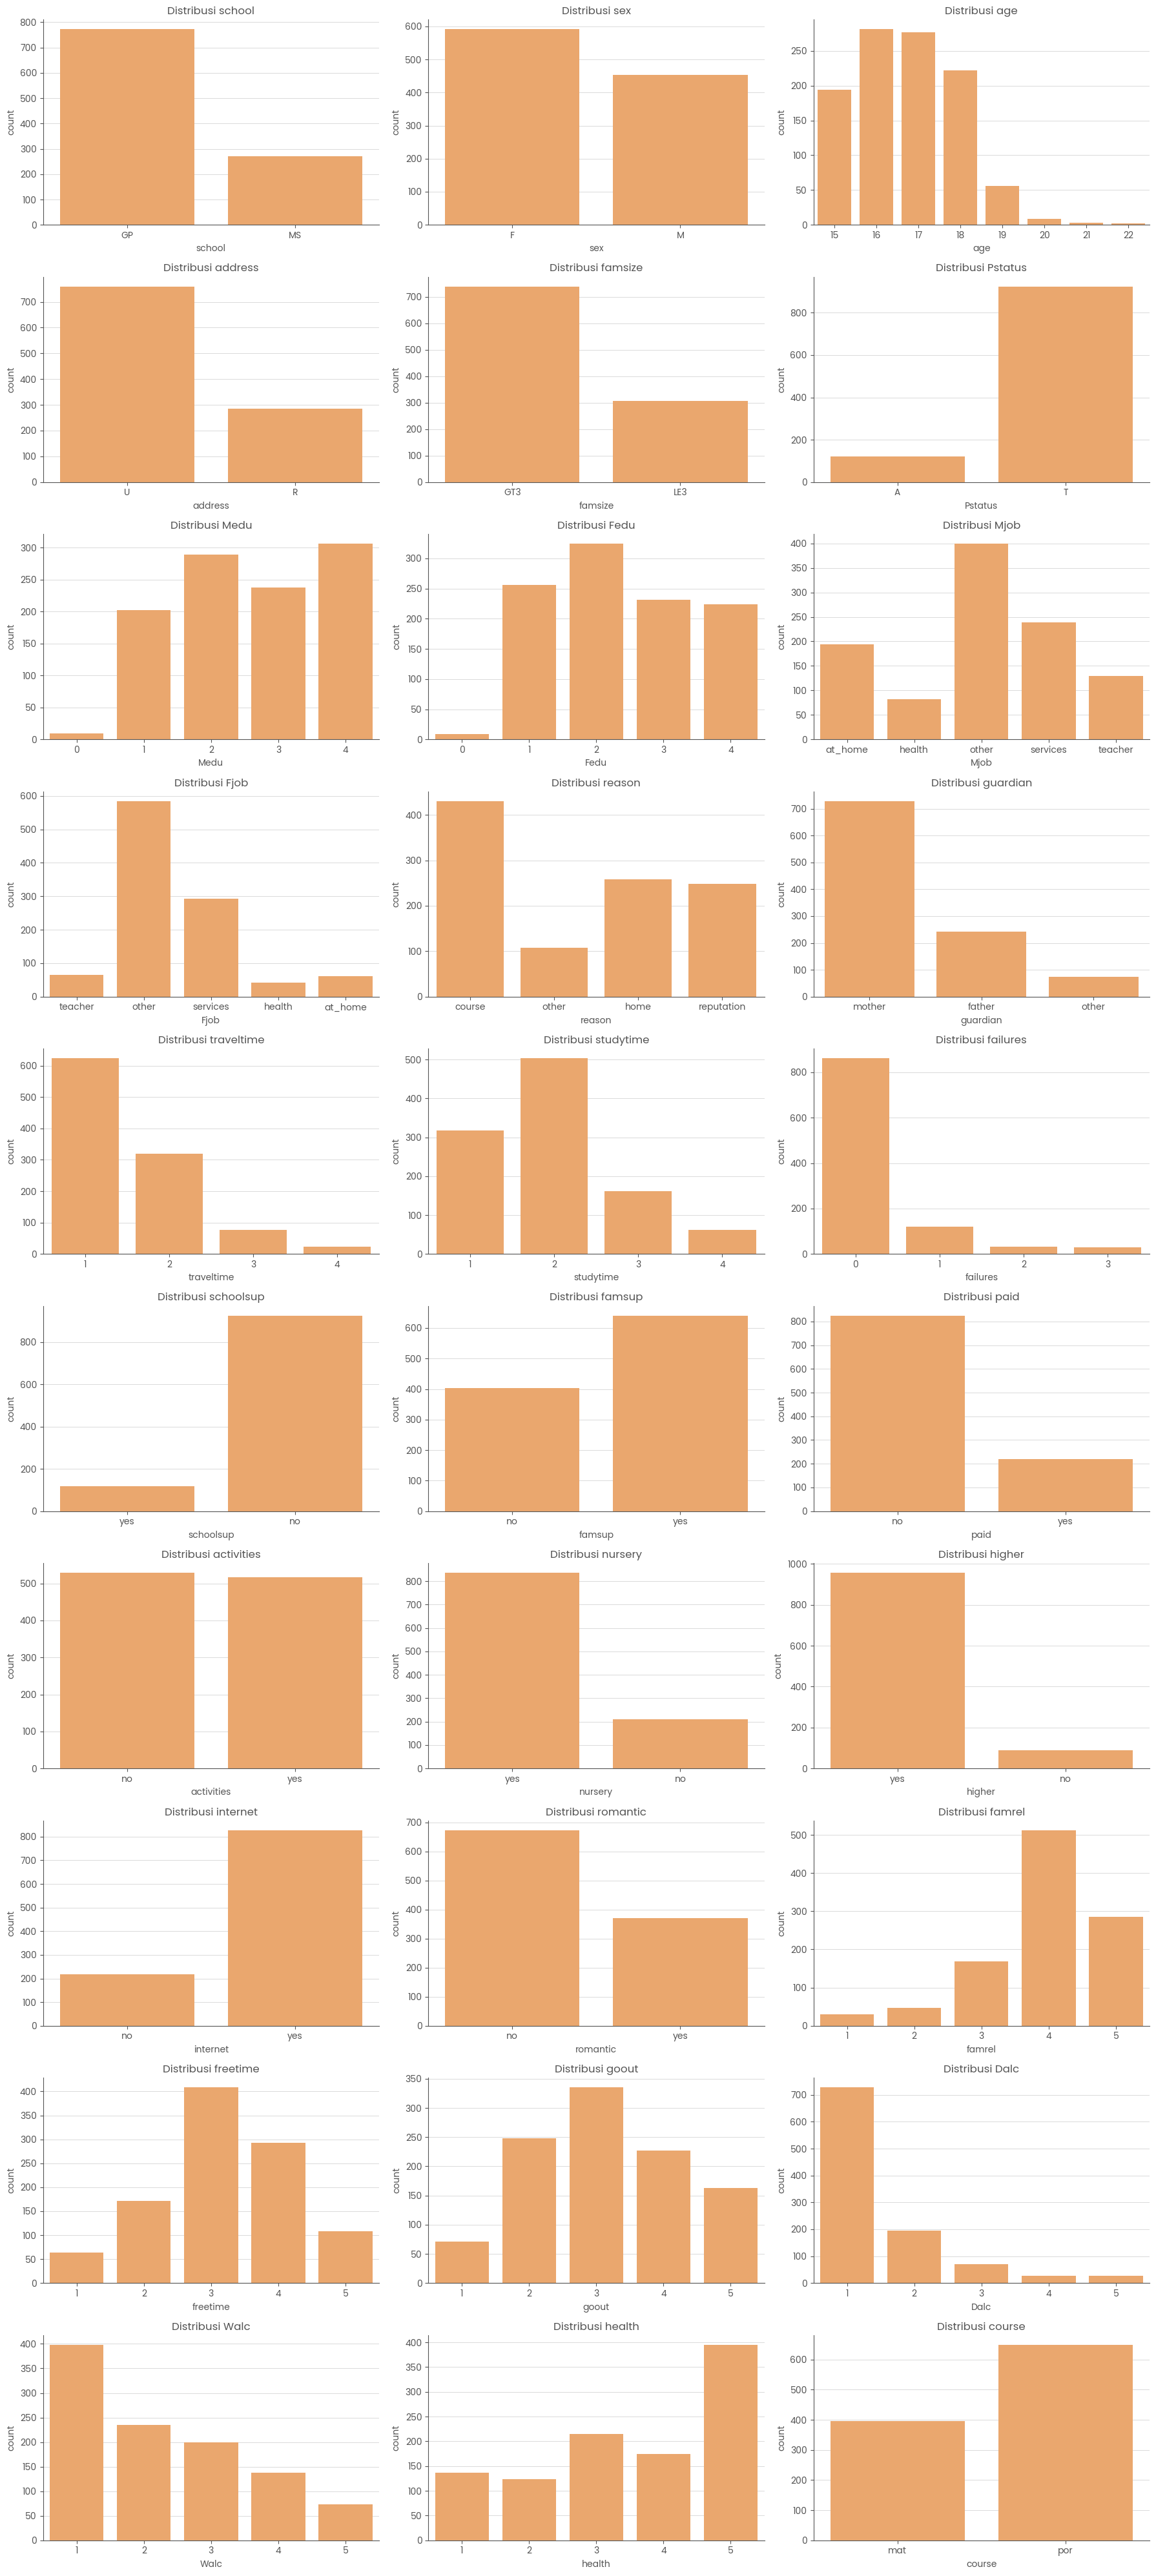

In [ ]:
# Menampilkan visualisasi countplot
count_cols = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'course']
n_cols = 3
n_rows = 10

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(count_cols):
    sns.countplot(data=df, x=col, ax=axes[i], color=palette[3])
    axes[i].set_title(f'Distribusi {col}')

for j in range(len(count_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

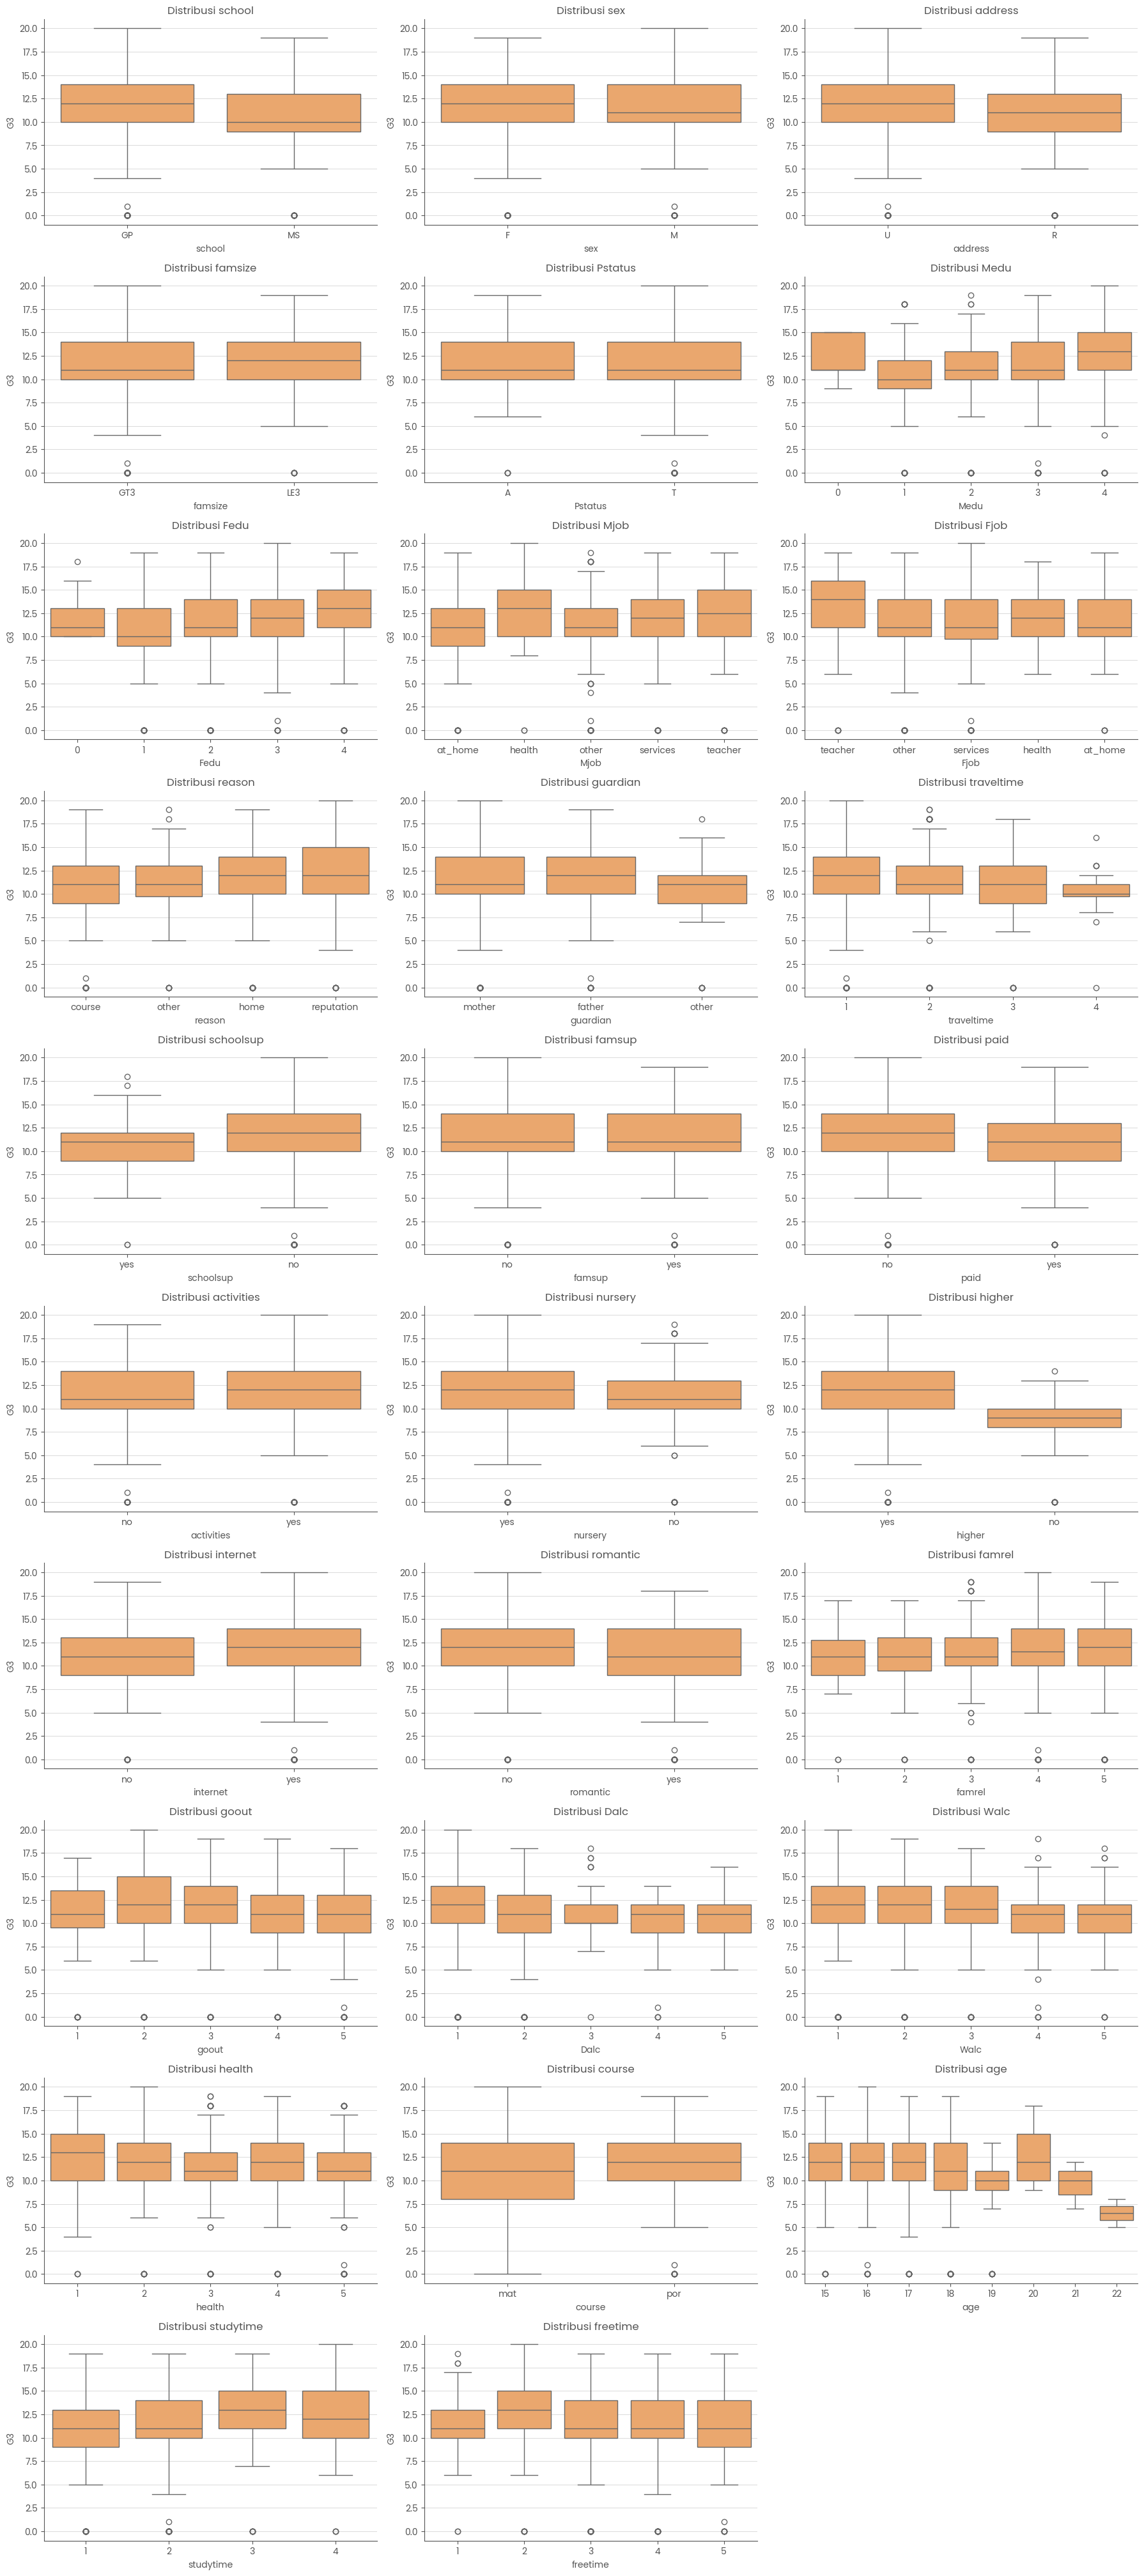

In [ ]:
# Menampilkan visualisasi hubungan prediktor dengan target
box_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
            'Fjob', 'reason', 'guardian', 'traveltime', 'schoolsup', 'famsup', 'paid',
            'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'goout',
            'Dalc', 'Walc', 'health', 'course', 'age', 'studytime', 'freetime']
n_cols = 3
n_rows = 11

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    sns.boxplot(data=df, x=col, y='G3', ax=axes[i], color=palette[3])
    axes[i].set_title(f'Distribusi {col}')

for j in range(len(box_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

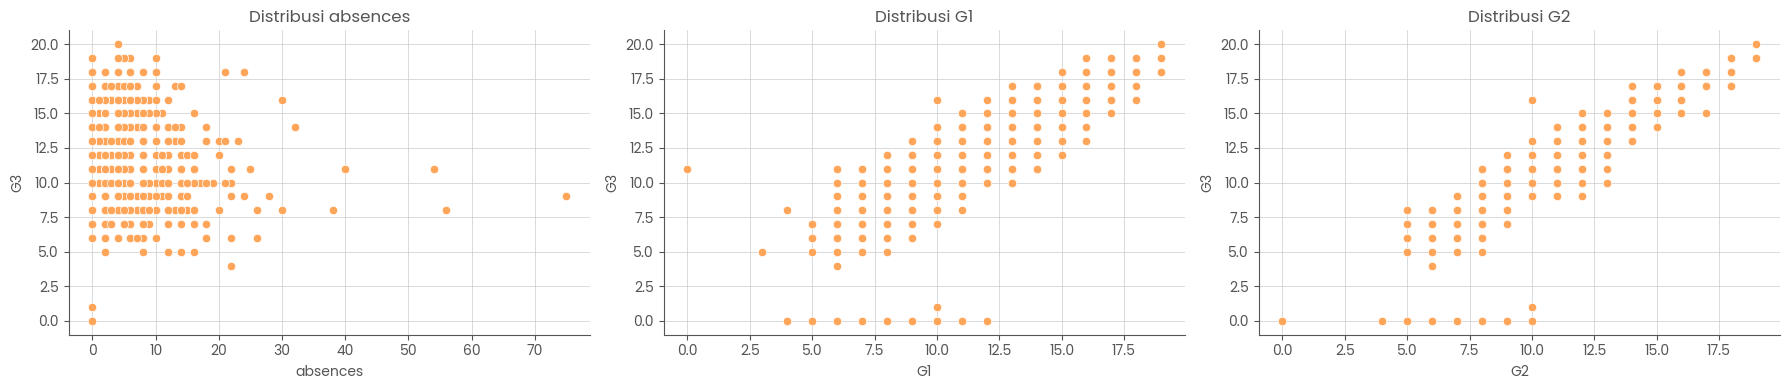

In [ ]:
# Menampilkan visualisasi hubungan prediktor dengan target
scatter_cols = ['absences', 'G1', 'G2']
n_cols = 3
n_rows = 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(scatter_cols):
    sns.scatterplot(data=df, x=col, y='G3', ax=axes[i], color=palette[3])
    axes[i].set_title(f'Distribusi {col}')

for j in range(len(scatter_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

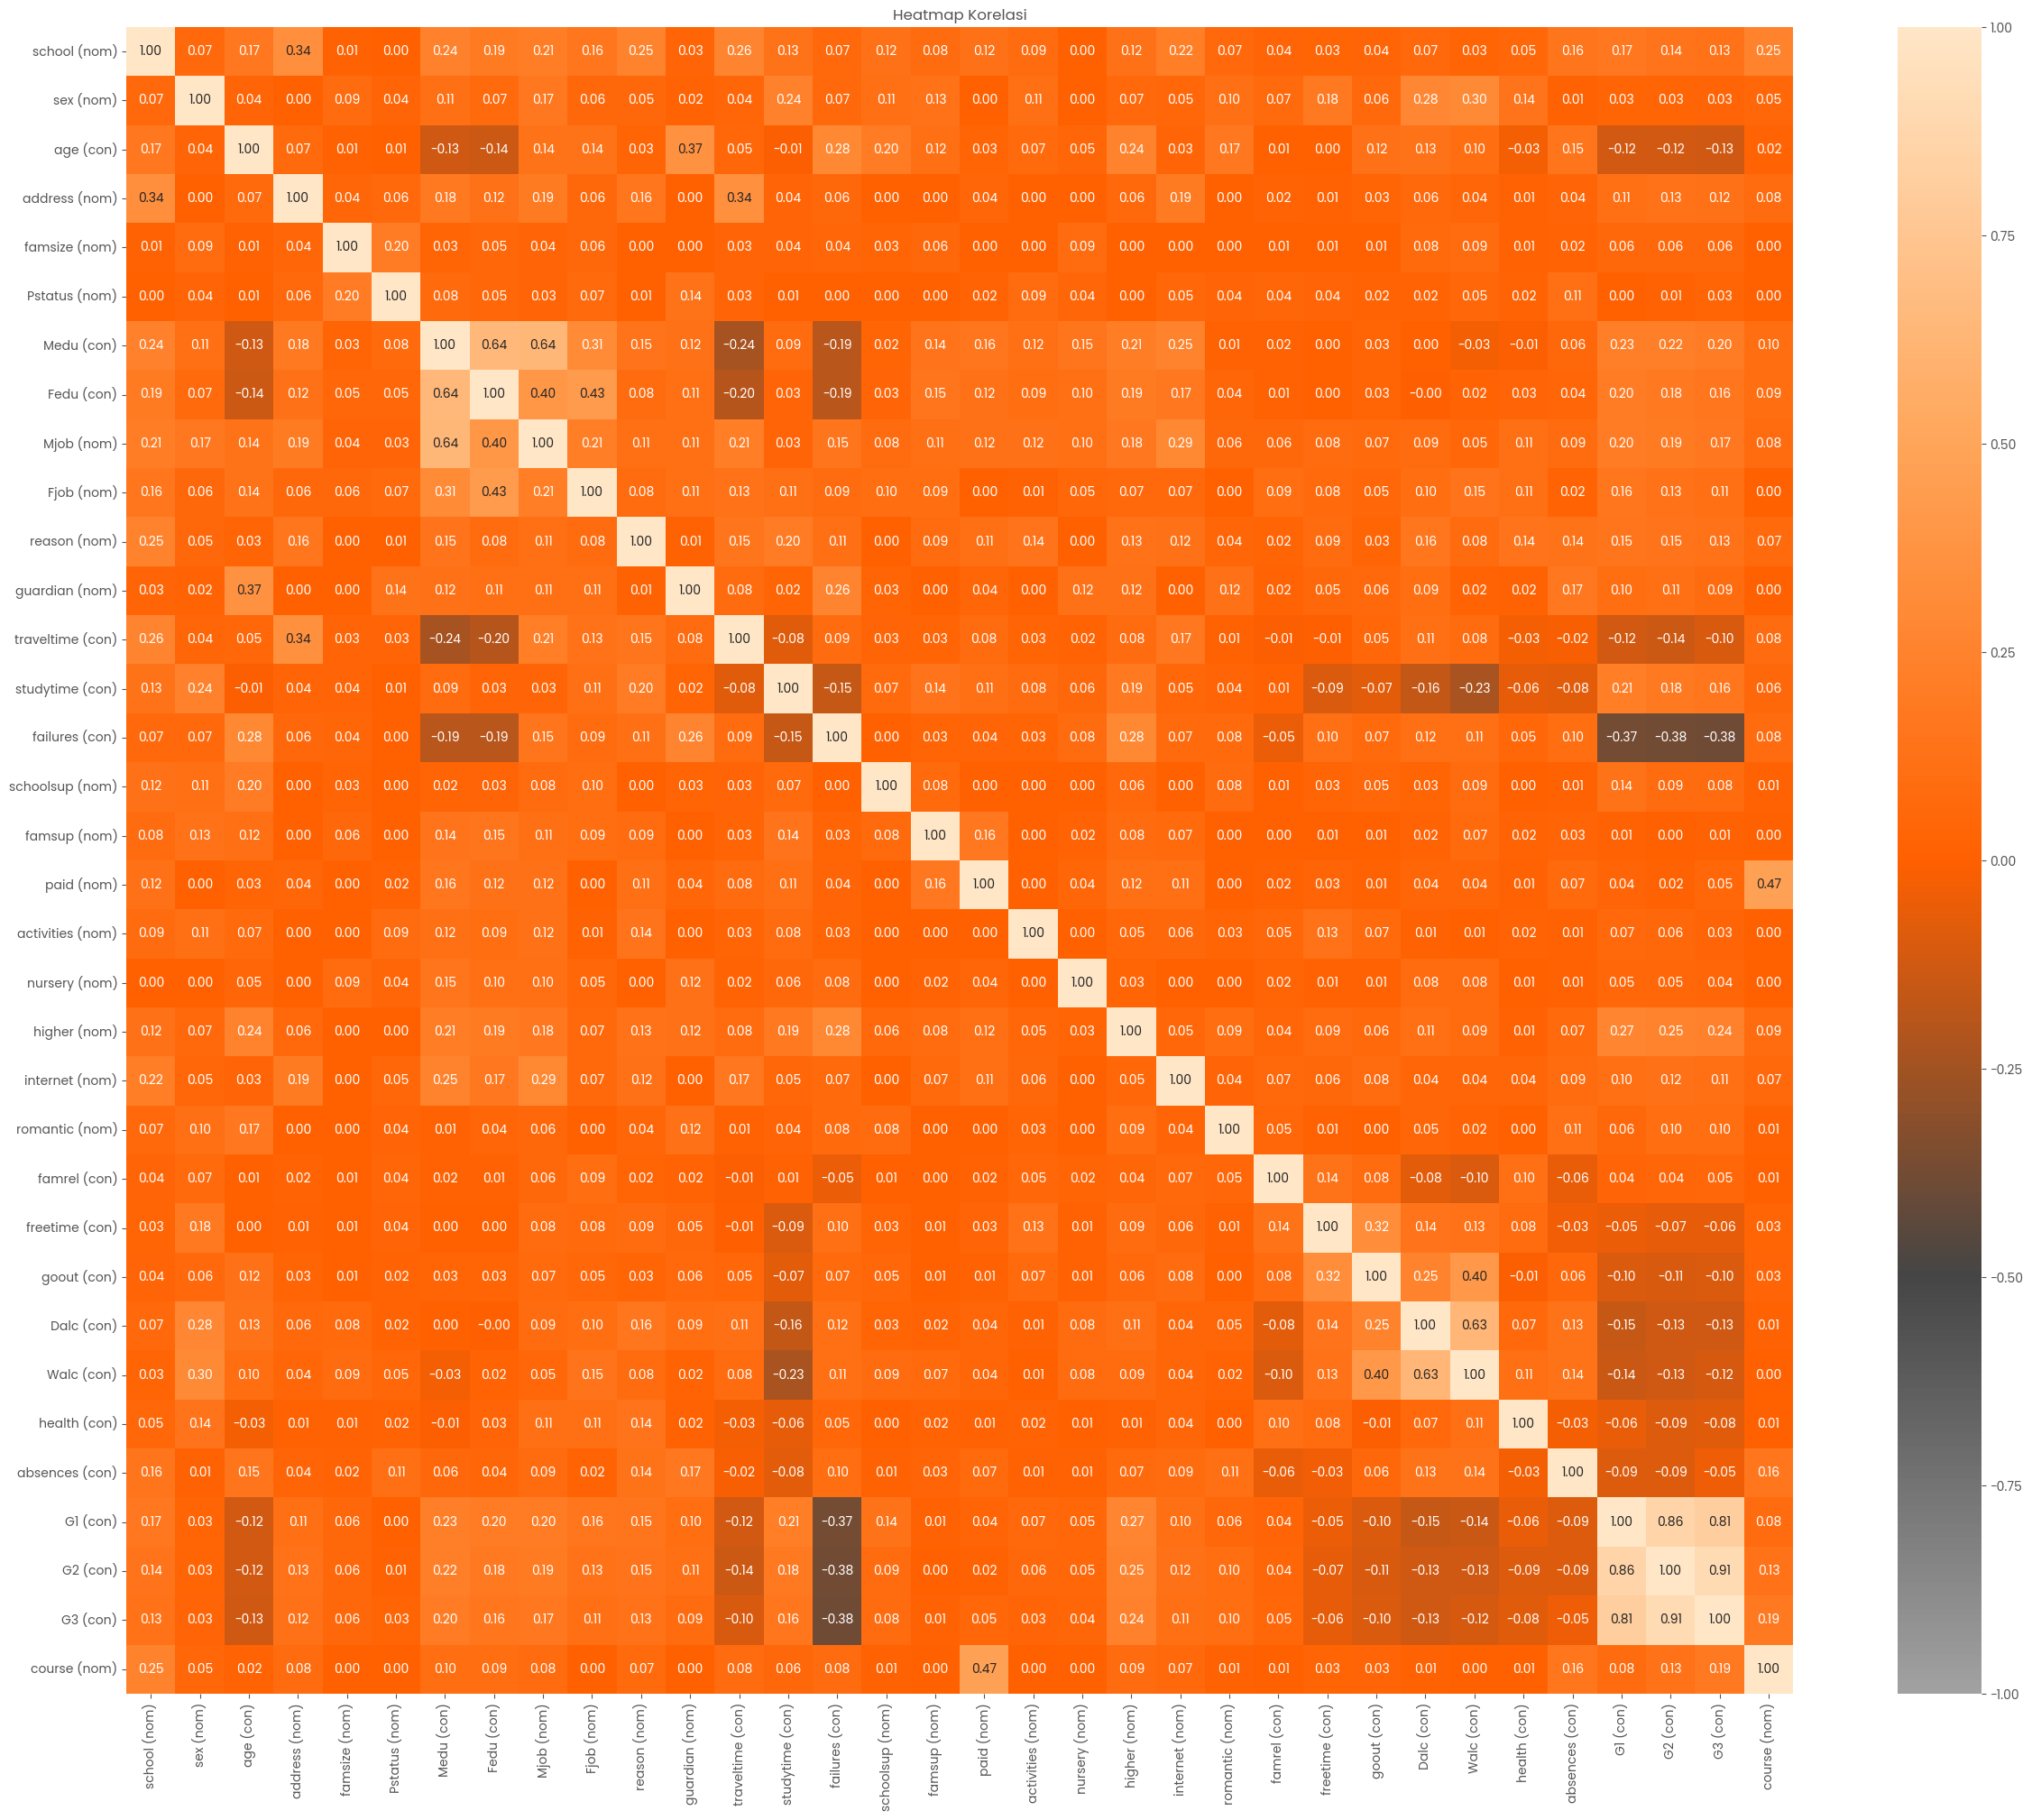

In [ ]:
# Menampilkan heatmap korelasi
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", palette)
nom_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'course']
assoc = associations(df, nominal_columns=nom_cols, figsize=(30, 24), mark_columns=True, cmap=custom_cmap, title='Heatmap Korelasi')

### Screening Awal

In [ ]:
def anova_test(df, cat_col, num_col):
    """Test perbedaan mean antar kategori"""
    groups = [group[num_col].values for name, group in df.groupby(cat_col)]
    f_stat, p_value = f_oneway(*groups)
    return p_value

for col in cat_cols:
    p_val = anova_test(df, col, 'G3')
    if p_val < 0.05:
      print(f"{col}: p-value = {p_val:.4f}")

school: p-value = 0.0000
address: p-value = 0.0001
famsize: p-value = 0.0480
Mjob: p-value = 0.0000
Fjob: p-value = 0.0090
reason: p-value = 0.0005
guardian: p-value = 0.0105
schoolsup: p-value = 0.0103
higher: p-value = 0.0000
internet: p-value = 0.0005
romantic: p-value = 0.0015
course: p-value = 0.0000


In [ ]:
def correlation_significance(df, col1, col2):
    """Test signifikansi korelasi"""
    corr, p_value = pearsonr(df[col1], df[col2])
    return corr, p_value

# Korelasi Pearson
results = []
for col in num_cols:
    if col != 'G3':
        corr, p_val = correlation_significance(df, col, 'G3')
        results.append({
            'variable': col,
            'correlation': corr,
            'p_value': p_val,
            'significant': p_val < 0.05,
            'abs_corr': abs(corr)
        })

corr_df = pd.DataFrame(results)

# Mutual Information
numerical_features = df[num_cols].drop('G3', axis=1)
mi_scores = mutual_info_regression(numerical_features, df['G3'])

mi_df = pd.DataFrame({
    'variable': numerical_features.columns,
    'mutual_info': mi_scores
})

# Gabungkan berdasarkan 'variable'
merged_df = pd.merge(corr_df, mi_df, on='variable')

# Urutkan berdasarkan |correlation| atau mutual_info
merged_df = merged_df.sort_values(['abs_corr'], ascending=False)
display(merged_df)

,variable,correlation,p_value,significant,abs_corr,mutual_info
14,G2,0.910743,0.000000e+00,True,0.910743,1.266075
13,G1,0.809142,7.556322e-243,True,0.809142,0.768281
5,failures,-0.383145,7.665909e-38,True,0.383145,0.126407
1,Medu,0.201472,5.050894e-11,True,0.201472,0.056254
4,studytime,0.161629,1.515269e-07,True,0.161629,0.014494
2,Fedu,0.159796,2.098770e-07,True,0.159796,0.020337
9,Dalc,-0.129642,2.650469e-05,True,0.129642,0.018552
0,age,-0.125282,4.925115e-05,True,0.125282,0.000000
10,Walc,-0.115740,1.783956e-04,True,0.115740,0.027289
3,traveltime,-0.102627,8.976537e-04,True,0.102627,0.000000


* school (p=0.0000) - Perbedaan antar sekolah sangat signifikan
* higher (p=0.0000) - Aspirasi kuliah vs tidak
* course (p=0.0000) - Mata pelajaran berbeda
* Mjob (p=0.0000) - Pekerjaan ibu berpengaruh
* G1, G2 (corr=0.81, 0.91) - Grades sebelumnya, predictor terkuat
* failures (corr=-0.38) - Jumlah kegagalan, efek besar
* internet (p=0.0005) - Akses internet
* reason (p=0.0005) - Alasan pilih sekolah
* romantic (p=0.0015) - Hubungan romantis
* Medu (corr=0.20) - Pendidikan ibu
* studytime (corr=0.16) - Waktu belajar
* Fedu (corr=0.16) - Pendidikan ayah
* absences (MI=0.085) - Ketidakhadiran (mutual info tinggi!)
* goout going out with friends (numeric: from 1 - very low to 5 - very high)

### Analisis Nilai Siswa

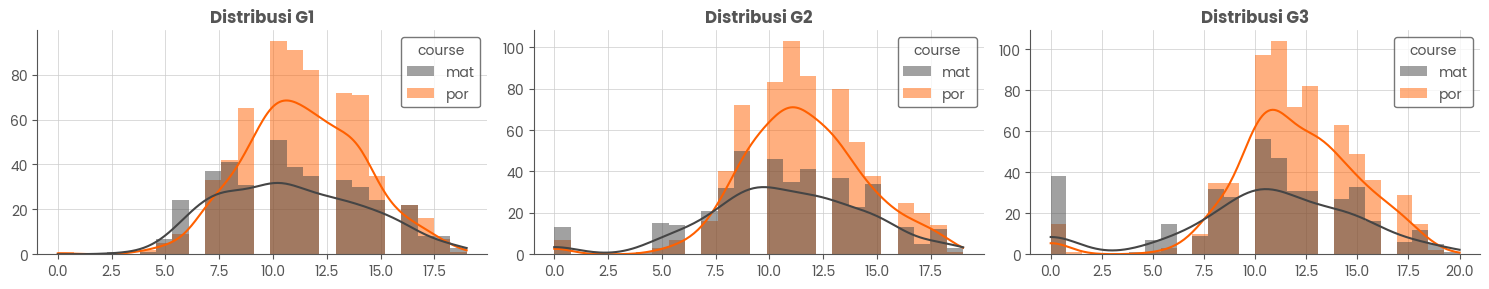

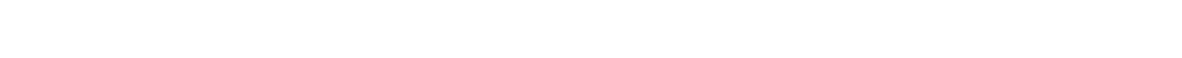

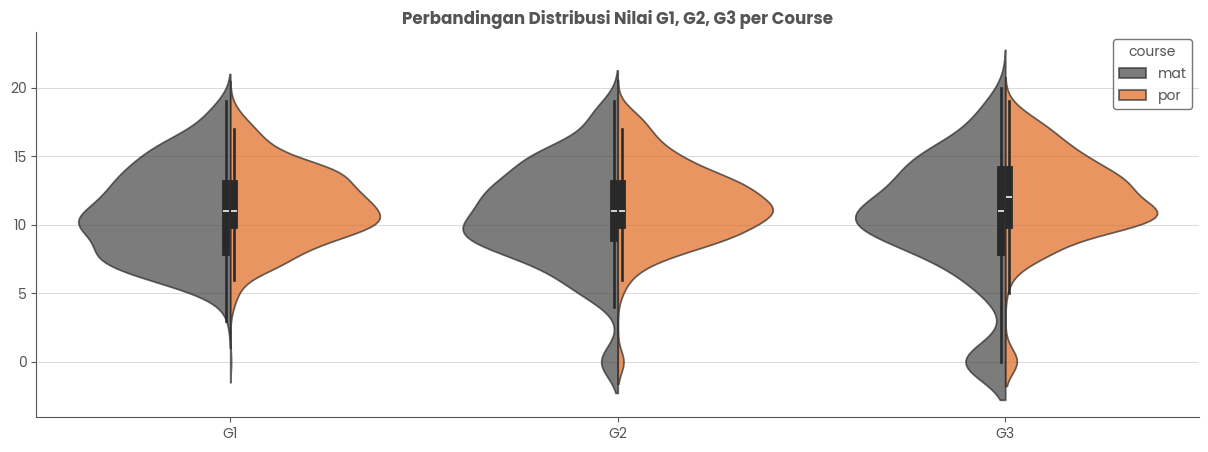

In [ ]:
# Distribusi Nilai (G1, G2, G3)
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

sns.histplot(data=df, x="G1", hue="course", kde=True, ax=axes[0], palette=palette[1:3], edgecolor='none')
axes[0].set_title("Distribusi G1", fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

sns.histplot(data=df, x="G2", hue="course", kde=True, ax=axes[1], palette=palette[1:3], edgecolor='none')
axes[1].set_title("Distribusi G2", fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

sns.histplot(data=df, x="G3", hue="course", kde=True, ax=axes[2], palette=palette[1:3], edgecolor='none')
axes[2].set_title("Distribusi G3", fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig('hist_nilai.png', transparent=True, dpi=800)
plt.show()

plt.figure(figsize=(15, 0.5))
plt.axis('off')
plt.show()

df_melted = df.melt(id_vars=['course'], value_vars=['G1', 'G2', 'G3'], var_name='Grade', value_name='Score')
plt.figure(figsize=(15, 5))
sns.violinplot(data=df_melted, x='Grade', y='Score', hue='course', split=True, palette=palette[1:3], alpha=0.7)
plt.title("Perbandingan Distribusi Nilai G1, G2, G3 per Course", fontweight='bold')
plt.xlabel("")
plt.ylabel("")
plt.savefig('viol_nilai.png', transparent=True, dpi=800)
plt.show()

#### **Temuan**

1. **Nilai Bahasa Portugis Jauh Lebih Bagus**

  Secara umum, nilai rata-rata siswa di pelajaran Bahasa Portugis lebih tinggi daripada di Matematika.

2. **Banyak yang Gagal Total di Matematika**

  Ada hal yang mengkhawatirkan di pelajaran Matematika. Banyak sekali siswa yang dapat nilai nol. Sedangkan di pelajaran Bahasa Portugis ini tidak terjadi.

3. **Pola Nilai yang Berbeda**

  Di pelajaran Bahasa Portugis, kebanyakan nilai siswa mengumpul di tengah. Artinya, tidak banyak yang nilainya jelek sekali atau bagus sekali. Hasilnya cukup merata di level sedang-ke-atas. Di pelajaran Matematika, siswanya seperti terbagi dua: ada kelompok yang nilainya lumayan (di tengah), dan ada kelompok lain yang nilainya sangat rendah.

4. **Perkembangan Sepanjang Tahun**

  Nilai Bahasa Portugis anak-anak cenderung stabil dari ujian pertama sampai ujian akhir. Untuk Matematika, siswa yang dari awal sudah kesulitan, kelihatannya akan terus kesulitan sampai akhir tahun.

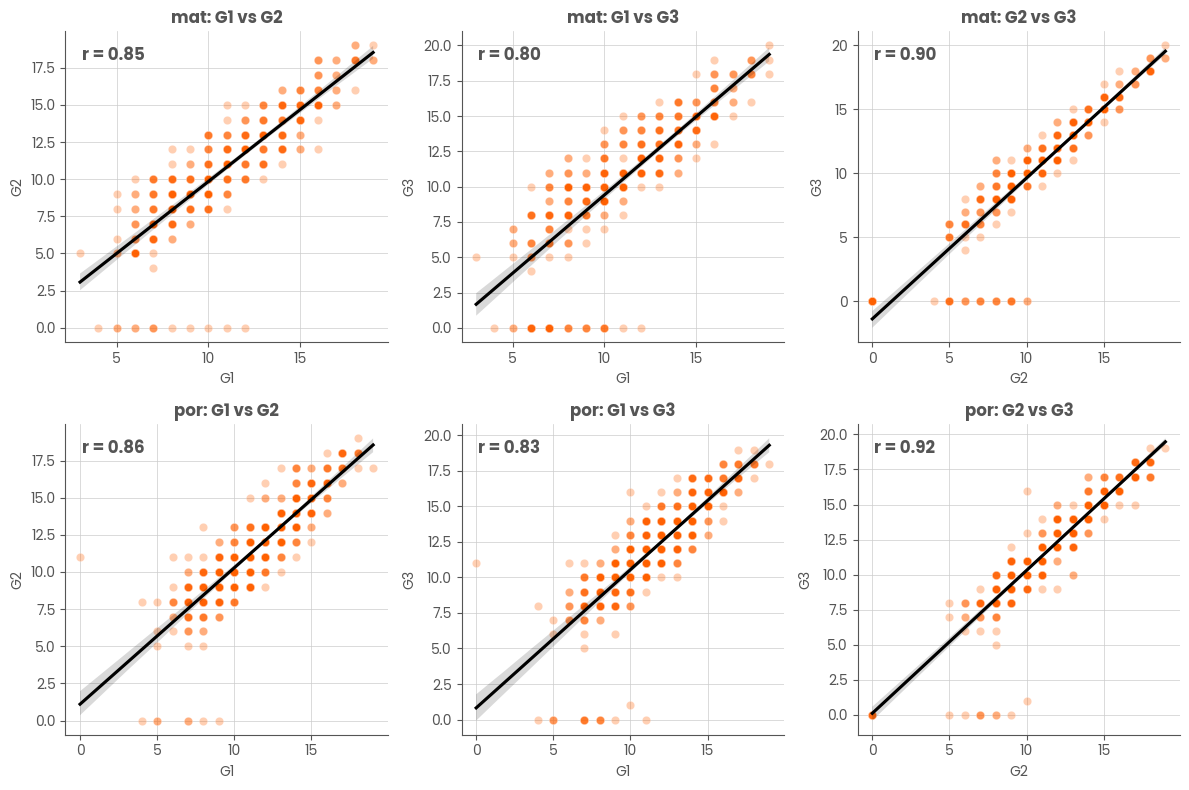

In [ ]:
# Korelasi antara G1, G2, dan G3
courses = ["mat", "por"]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, course in enumerate(courses):
    df_course = df[df["course"] == course]

    corr_g1g2 = df_course["G1"].corr(df_course["G2"])
    corr_g1g3 = df_course["G1"].corr(df_course["G3"])
    corr_g2g3 = df_course["G2"].corr(df_course["G3"])

    sns.scatterplot(data=df_course, x="G1", y="G2", alpha=0.3, ax=axes[i, 0], color=palette[2])
    sns.regplot(data=df_course, x="G1", y="G2", scatter=False, line_kws={"color": "black"}, ax=axes[i, 0])
    axes[i, 0].set_title(f"{course}: G1 vs G2", fontweight='bold')
    axes[i, 0].text(0.05, 0.95, f"r = {corr_g1g2:.2f}", transform=axes[i, 0].transAxes, fontsize=12, fontweight='bold', va='top')

    sns.scatterplot(data=df_course, x="G1", y="G3", alpha=0.3, ax=axes[i, 1], color=palette[2])
    sns.regplot(data=df_course, x="G1", y="G3", scatter=False, line_kws={"color": "black"}, ax=axes[i, 1])
    axes[i, 1].set_title(f"{course}: G1 vs G3", fontweight='bold')
    axes[i, 1].text(0.05, 0.95, f"r = {corr_g1g3:.2f}", transform=axes[i, 1].transAxes, fontsize=12, fontweight='bold', va='top')

    sns.scatterplot(data=df_course, x="G2", y="G3", alpha=0.3, ax=axes[i, 2], color=palette[2])
    sns.regplot(data=df_course, x="G2", y="G3", scatter=False, line_kws={"color": "black"}, ax=axes[i, 2])
    axes[i, 2].set_title(f"{course}: G2 vs G3", fontweight='bold')
    axes[i, 2].text(0.05, 0.95, f"r = {corr_g2g3:.2f}", transform=axes[i, 2].transAxes, fontsize=12, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('grade_corr.png', transparent=True, dpi=800)
plt.show()

#### **Temuan**

1.  **Nilai Siswa Sangat Konsisten**
    
    Pola nilainya sangat jelas. Siswa yang dapat nilai bagus di ujian pertama, hampir pasti dapat nilai bagus lagi di ujian berikutnya. Sebaliknya, siswa yang nilainya kurang di awal, cenderung akan terus kurang sampai akhir. Sederhananya: posisi peringkat siswa jarang sekali berubah.

2.  **Nilai Ujian Tengah Semester adalah Petunjuk Terbaik**
    
    Jika kita ingin menebak berapa nilai akhir seorang siswa, maka nilai ujian tengah semester (nilai G2) adalah petunjuk yang paling akurat. Ini lebih akurat daripada menggunakan nilai dari awal semester (nilai G1).

3.  **Nilai Bahasa Portugis Sedikit Lebih Stabil**
    
    Konsistensi nilai ini (poin 1) sedikit lebih kuat di pelajaran Bahasa Portugis. Artinya, nilai siswa di pelajaran Bahasa Portugis sedikit lebih "mudah ditebak" dari ujian ke ujian, sementara di Matematika kadang bisa sedikit lebih naik-turun.

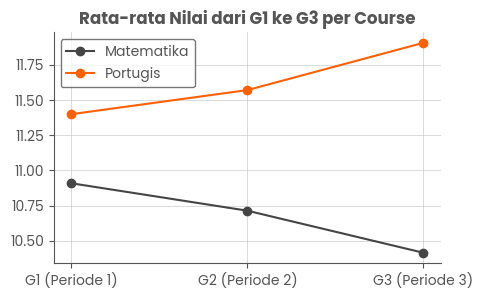

In [ ]:
# Perkembangan Nilai dari G1 ke G3
mean_grades_mat = df[df['course'] == 'mat'][["G1", "G2", "G3"]].mean()
mean_grades_por = df[df['course'] == 'por'][["G1", "G2", "G3"]].mean()

plt.figure(figsize=(5, 3))
plt.plot(mean_grades_mat.index, mean_grades_mat.values, marker="o", linestyle="-", label="Matematika", color=palette[1])
plt.plot(mean_grades_por.index, mean_grades_por.values, marker="o", linestyle="-", label="Portugis", color=palette[2])

plt.title("Rata-rata Nilai dari G1 ke G3 per Course", fontweight='bold')
plt.xlabel("")
plt.ylabel("")
plt.xticks([0, 1, 2], ["G1 (Periode 1)", "G2 (Periode 2)", "G3 (Periode 3)"])
plt.grid(True)
plt.legend()
plt.savefig('grad_overtime.png', transparent=True, dpi=800)
plt.show()

#### **Temuan**

1.  **Keunggulan Performa pada Bahasa Portugis**

  Di setiap periode evaluasi (G1, G2, G3), nilai rata-rata siswa untuk Bahasa Portugis secara konsisten lebih tinggi dibandingkan nilai rata-rata untuk Matematika.

2.  **Tren Perkembangan yang Berlawanan**

  Terdapat dua tren yang kontradiktif seiring berjalannya waktu. Bahasa Portugis menunjukkan tren positif, di mana nilai rata-rata siswa terus meningkat dari periode awal hingga akhir. Matematika menunjukkan tren negatif, di mana nilai rata-rata siswa justru menurun secara progresif sepanjang tahun ajaran.

3.  **Peningkatan Disparitas Prestasi**

  Sebagai akibat dari dua tren yang berlawanan tersebut, kesenjangan performa antara kedua mata pelajaran menjadi semakin signifikan. Perbedaan nilai rata-rata di akhir periode (G3) jauh lebih besar daripada di awal periode (G1).

### Analisis Demografi

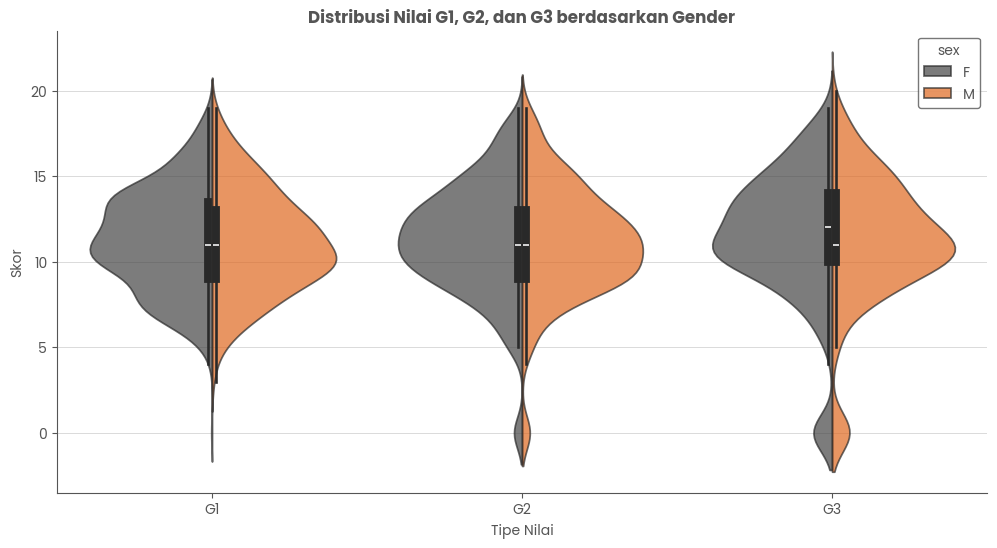

In [ ]:
# Perbandingan nilai antara gender
df_long = df.melt(id_vars='sex', value_vars=['G1', 'G2', 'G3'], var_name='Nilai', value_name='Skor')

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_long, x='Nilai', y='Skor', hue='sex', split=True, palette=palette[1:3], alpha=0.7)

plt.title("Distribusi Nilai G1, G2, dan G3 berdasarkan Gender", fontweight='bold')
plt.xlabel("Tipe Nilai")
plt.ylabel("Skor")
plt.savefig('gender.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan hubungan gender
result_df = ttest_with_effect_size(df, group_col='sex', group1='M', group2='F', features=['G1', 'G2', 'G3'], alpha=0.05)
result_df

,Fitur,Rata-rata M,Rata-rata F,Selisih rata-rata,p-value,Kesimpulan,Effect size (Cohen's d),Interpretasi Effect Size
0,G1,11.128035,11.279188,0.151152,0.417020,Tidak signifikan,0.050656,sangat kecil
1,G2,11.152318,11.318105,0.165787,0.419083,Tidak signifikan,0.050458,sangat kecil
2,G3,11.203091,11.448393,0.245302,0.309313,Tidak signifikan,0.063472,sangat kecil


Berdasarkan analisis data di atas, tidak ditemukan perbedaan prestasi belajar yang berarti antara siswa laki-laki dan perempuan. Kesimpulan ini berdasarkan grafik sebaran nilai menunjukkan pola yang hampir identik untuk kedua gender di semua periode ujian. Hasil perhitungan formal juga mengonfirmasi hal ini.

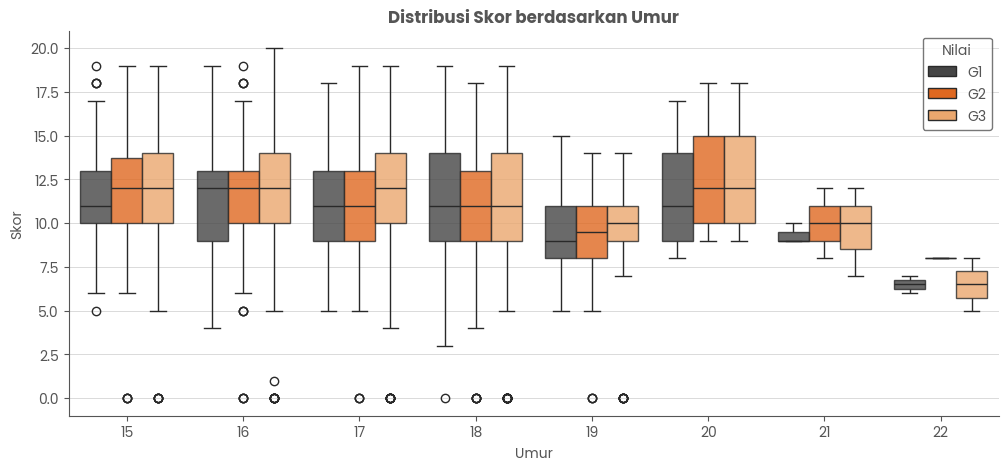

In [ ]:
# Perbandingan nilai antara usia
df_long = df.melt(id_vars='age', value_vars=['G1', 'G2', 'G3'], var_name='Nilai', value_name='Skor')

plt.figure(figsize=(12, 5))
ax = sns.boxplot(data=df_long, x='age', y='Skor', hue='Nilai', palette=palette[1:4])
for patch in ax.patches:
    patch.set_alpha(0.8)
plt.title("Distribusi Skor berdasarkan Umur", fontweight='bold')
plt.xlabel("Umur")
plt.ylabel("Skor")
plt.savefig('age.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan usia
result_corr = pearson_corr_with_strength(df, x_col='age', features=['G1', 'G2', 'G3'], alpha=0.05)
result_corr

,Fitur,Koefisien Korelasi (r),p-value,Kesimpulan,Kekuatan Korelasi
0,G1,-0.124121,0.000058,Signifikan,lemah
1,G2,-0.119475,0.000109,Signifikan,lemah
2,G3,-0.125282,0.000049,Signifikan,lemah


Analisis data di atas menunjukkan bahwa semakin tua umur siswa, nilainya cenderung sedikit lebih rendah. Namun, pengaruh umur ini sangat kecil dan tidak terlalu berarti. Ada banyak faktor lain yang jauh lebih penting dalam menentukan nilai siswa daripada sekadar umurnya.

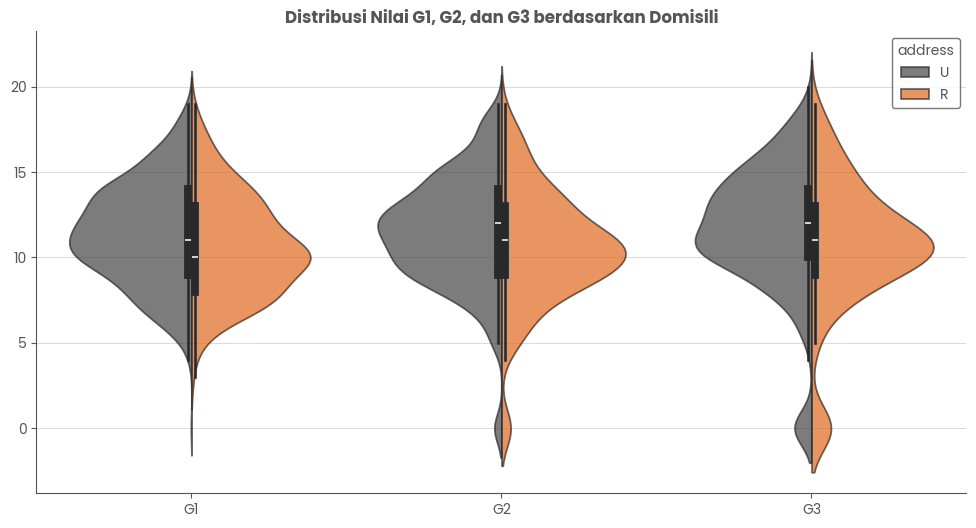

In [ ]:
# Perbandingan nilai antar domisili
df_long = df.melt(id_vars='address', value_vars=['G1', 'G2', 'G3'],var_name='Nilai', value_name='Skor')

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_long, x='Nilai', y='Skor', hue='address', split=True, palette=palette[1:3], alpha=0.7)

plt.title("Distribusi Nilai G1, G2, dan G3 berdasarkan Domisili", fontweight='bold')
plt.xlabel("")
plt.ylabel("")
plt.savefig('address.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan domisili
result_df = ttest_with_effect_size(df, group_col='address', group1='U', group2='R', features=['G1', 'G2', 'G3'], alpha=0.05)
result_df

,Fitur,Rata-rata U,Rata-rata R,Selisih rata-rata,p-value,Kesimpulan,Effect size (Cohen's d),Interpretasi Effect Size
0,G1,11.420290,10.663158,-0.757132,0.000253,Signifikan,-0.255299,kecil
1,G2,11.503294,10.561404,-0.941890,0.000059,Signifikan,-0.288950,kecil
2,G3,11.620553,10.600000,-1.020553,0.000207,Signifikan,-0.265785,kecil


Analisis data di atas menunjukkan bahwa siswa yang tinggal di daerah urban memiliki nilai yang cenderung lebih tinggi dari pada siswa yang tinggal di daerah rural. Namun, pengaruh tempat tinggal ini sangat kecil dan tidak terlalu berarti. Ada banyak faktor lain yang jauh lebih penting dalam menentukan nilai siswa daripada sekadar umurnya.

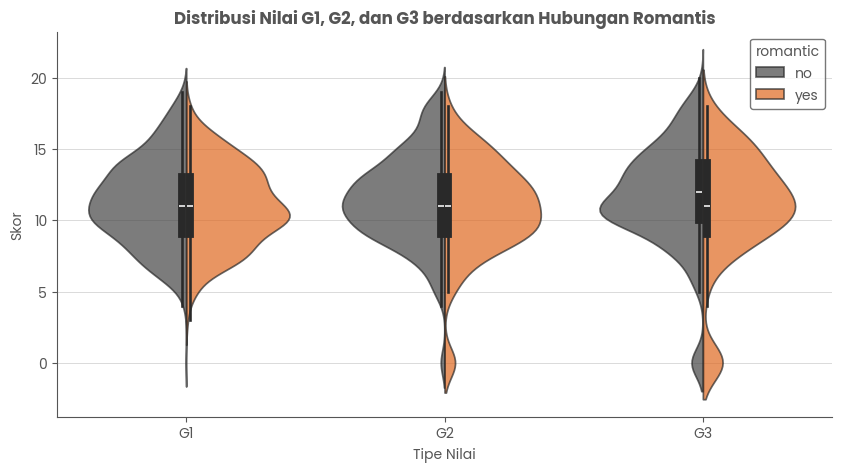

In [ ]:
# Perbandingan nilai antara hubungan romantis
df_long = df.melt(id_vars='romantic', value_vars=['G1', 'G2', 'G3'],
                  var_name='Nilai', value_name='Skor')

plt.figure(figsize=(10, 5))
sns.violinplot(data=df_long, x='Nilai', y='Skor', hue='romantic', split=True, palette=palette[1:3], alpha=0.7)

plt.title("Distribusi Nilai G1, G2, dan G3 berdasarkan Hubungan Romantis", fontweight='bold')
plt.xlabel("Tipe Nilai")
plt.ylabel("Skor")
plt.savefig('romantic.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan hubungan romantis
result_df = ttest_with_effect_size(df, group_col='romantic', group1='yes', group2='no', features=['G1', 'G2', 'G3'], alpha=0.05)
result_df

,Fitur,Rata-rata yes,Rata-rata no,Selisih rata-rata,p-value,Kesimpulan,Effect size (Cohen's d),Interpretasi Effect Size
0,G1,10.989218,11.337296,0.348077,0.065286,Tidak signifikan,0.116798,sangat kecil
1,G2,10.814016,11.484398,0.670382,0.001943,Signifikan,0.204952,kecil
2,G3,10.830189,11.624071,0.793883,0.002203,Signifikan,0.206316,kecil


Analisis data di atas menunjukkan bahwa siswa yang memiliki hubungan romantis cenderung memiliki nilai yang lebih rendah daripada siswa yang tidak memiliki hubungan romantis. Namun, pengaruh hubungan romantis ini sangat kecil dan tidak terlalu berarti. Ada banyak faktor lain yang jauh lebih penting dalam menentukan nilai siswa daripada sekadar umurnya.

### Analisis Faktor Akademik

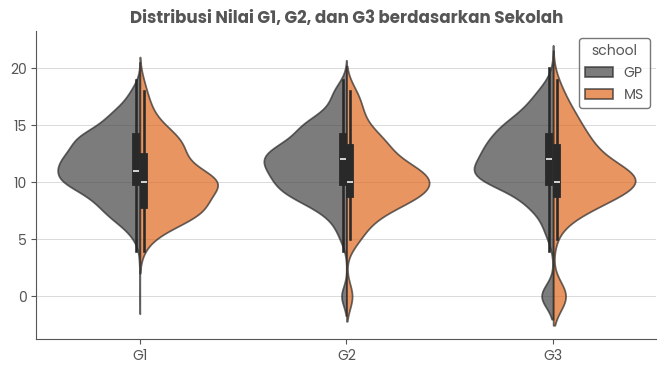

In [ ]:
# Perbandingan nilai antara sekolah
df_long = df.melt(id_vars='school', value_vars=['G1', 'G2', 'G3'], var_name='Nilai', value_name='Skor')

plt.figure(figsize=(8, 4))
sns.violinplot(data=df_long, x='Nilai', y='Skor', hue='school', split=True, palette=palette[1:3], alpha=0.7)

plt.title("Distribusi Nilai G1, G2, dan G3 berdasarkan Sekolah", fontweight='bold')
plt.xlabel("")
plt.ylabel("")
plt.savefig('school.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan sekolah
result_df = ttest_with_effect_size(df, group_col='school', group1='GP', group2='MS', features=['G1', 'G2', 'G3'], alpha=0.05)
result_df

,Fitur,Rata-rata GP,Rata-rata MS,Selisih rata-rata,p-value,Kesimpulan,Effect size (Cohen's d),Interpretasi Effect Size
0,G1,11.512953,10.363971,-1.148983,9.697092e-08,Signifikan,-0.390568,kecil
1,G2,11.528497,10.444853,-1.083644,5.120771e-06,Signifikan,-0.333226,kecil
2,G3,11.633420,10.514706,-1.118714,5.168325e-05,Signifikan,-0.291690,kecil


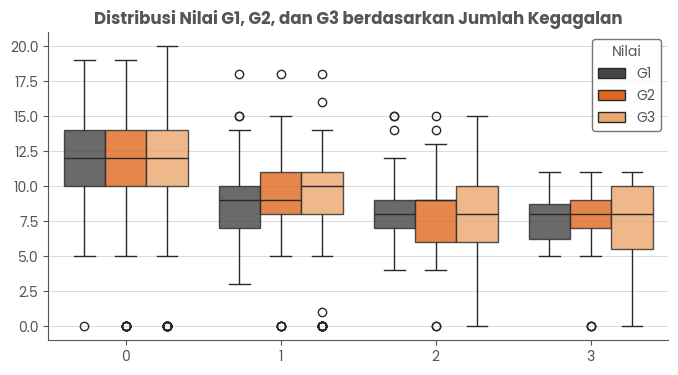

In [ ]:
# Perbandingan nilai antar jumlah kegagalan
df_long = df.melt(id_vars='failures', value_vars=['G1', 'G2', 'G3'], var_name='Nilai', value_name='Skor')

plt.figure(figsize=(8, 4))
ax = sns.boxplot(data=df_long, x='failures', y='Skor', hue='Nilai', palette=palette[1:4])
for patch in ax.patches:
    patch.set_alpha(0.8)
plt.title("Distribusi Nilai G1, G2, dan G3 berdasarkan Jumlah Kegagalan", fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.savefig('failures.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan jumlah kegagalan
result_corr = pearson_corr_with_strength(df, x_col='failures', features=['G1', 'G2', 'G3'], alpha=0.05)
result_corr

,Fitur,Koefisien Korelasi (r),p-value,Kesimpulan,Kekuatan Korelasi
0,G1,-0.374175,4.888813e-36,Signifikan,sedang
1,G2,-0.377172,1.237352e-36,Signifikan,sedang
2,G3,-0.383145,7.665909e-38,Signifikan,sedang


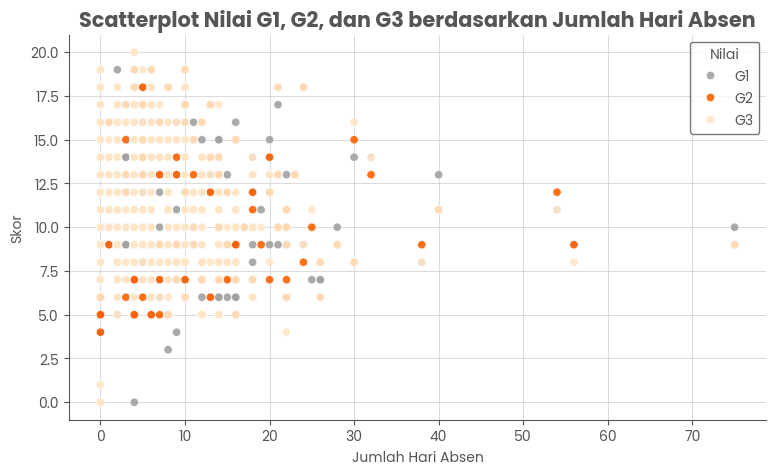

In [ ]:
# Perbandingan nilai antar jumlah hari absen
df_long = df.melt(id_vars='absences', value_vars=['G1', 'G2', 'G3'], var_name='Nilai', value_name='Skor')

plt.figure(figsize=(9, 5))
ax = sns.scatterplot(data=df_long, x='absences', y='Skor', hue='Nilai', palette=[palette[0], palette[2], palette[4]],alpha=0.9)

plt.title("Scatterplot Nilai G1, G2, dan G3 berdasarkan Jumlah Hari Absen", fontweight='bold', fontsize=15)
plt.xlabel("Jumlah Hari Absen")
plt.ylabel("Skor")
plt.savefig('absences.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan jumlah hari absen
result_corr = pearson_corr_with_strength(df, x_col='absences', features=['G1', 'G2', 'G3'], alpha=0.05)
result_corr

,Fitur,Koefisien Korelasi (r),p-value,Kesimpulan,Kekuatan Korelasi
0,G1,-0.092425,0.002798,Signifikan,sangat lemah
1,G2,-0.089332,0.003868,Signifikan,sangat lemah
2,G3,-0.045671,0.140303,Tidak signifikan,-


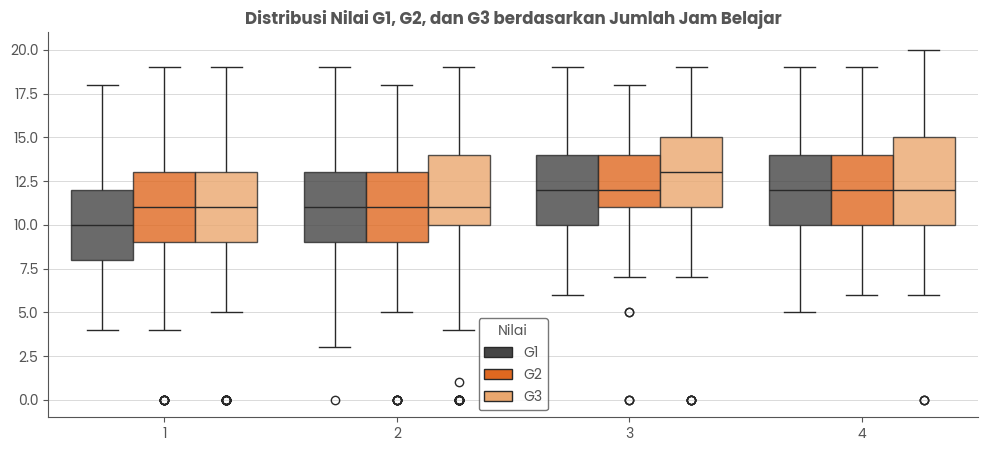

In [ ]:
# Perbandingan nilai antara jumlah jam belajar
df_long = df.melt(id_vars='studytime', value_vars=['G1', 'G2', 'G3'], var_name='Nilai', value_name='Skor')

plt.figure(figsize=(12, 5))
ax = sns.boxplot(data=df_long, x='studytime', y='Skor', hue='Nilai', palette=palette[1:4])
for patch in ax.patches:
    patch.set_alpha(0.8)
plt.title("Distribusi Nilai G1, G2, dan G3 berdasarkan Jumlah Jam Belajar", fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.savefig('studytime.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan jumlah jam belajar
result_corr = pearson_corr_with_strength(df, x_col='studytime', features=['G1', 'G2', 'G3'], alpha=0.05)
result_corr

,Fitur,Koefisien Korelasi (r),p-value,Kesimpulan,Kekuatan Korelasi
0,G1,0.211314,5.288222e-12,Signifikan,lemah
1,G2,0.183167,2.496064e-09,Signifikan,lemah
2,G3,0.161629,1.515269e-07,Signifikan,lemah


### Analisis Latar Belakang Keluarga

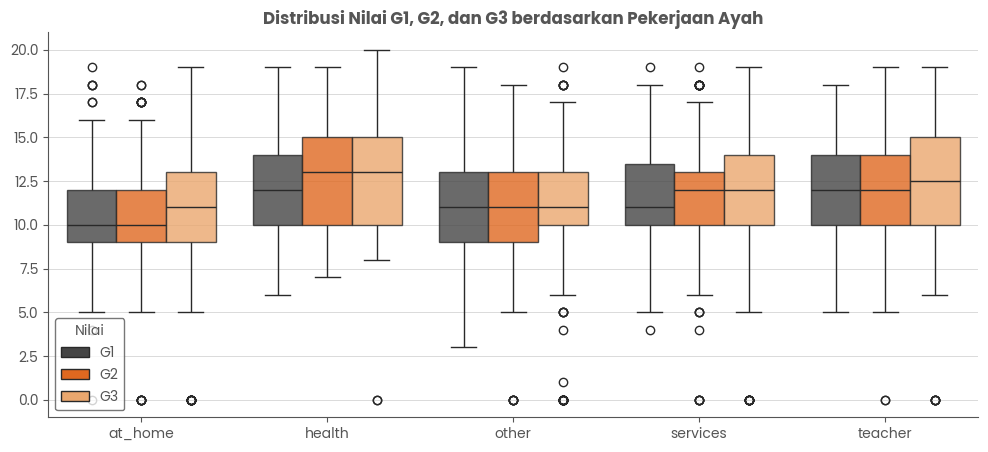

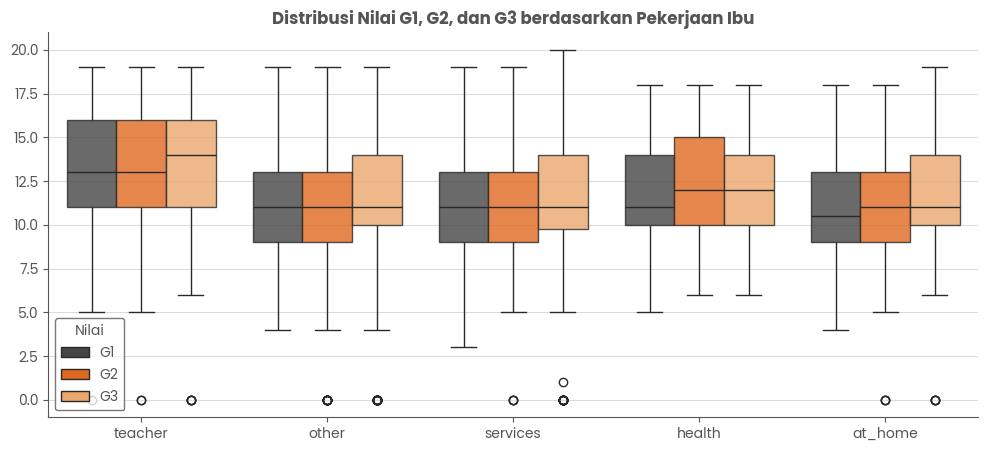

In [ ]:
# Perbandingan nilai antara pekerjaan orang tua
df_long = df.melt(id_vars='Mjob', value_vars=['G1', 'G2', 'G3'], var_name='Nilai', value_name='Skor')
plt.figure(figsize=(12, 5))
ax = sns.boxplot(data=df_long, x='Mjob', y='Skor', hue='Nilai', palette=palette[1:4])
for patch in ax.patches:
    patch.set_alpha(0.8)
plt.title("Distribusi Nilai G1, G2, dan G3 berdasarkan Pekerjaan Ayah", fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.savefig('Mjob.png', transparent=True, dpi=800)
plt.show()

df_long = df.melt(id_vars='Fjob', value_vars=['G1', 'G2', 'G3'], var_name='Nilai', value_name='Skor')
plt.figure(figsize=(12, 5))
ax = sns.boxplot(data=df_long, x='Fjob', y='Skor', hue='Nilai', palette=palette[1:4])
for patch in ax.patches:
    patch.set_alpha(0.8)
plt.title("Distribusi Nilai G1, G2, dan G3 berdasarkan Pekerjaan Ibu", fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.savefig('Fjob.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan pekerjaan orang tua
anova_result = anova_with_eta_squared(df, group_col='Mjob', features=['G1', 'G2', 'G3'], alpha=0.05)
display(anova_result)
anova_result = anova_with_eta_squared(df, group_col='Fjob', features=['G1', 'G2', 'G3'], alpha=0.05)
display(anova_result)

,Fitur,F-statistic,p-value,Kesimpulan,Eta Squared,Kekuatan Efek
0,G1,11.031655,9.153221e-09,Signifikan,0.040740,kecil
1,G2,9.530766,1.436972e-07,Signifikan,0.035393,kecil
2,G3,7.885915,2.915256e-06,Signifikan,0.029465,kecil


,Fitur,F-statistic,p-value,Kesimpulan,Eta Squared,Kekuatan Efek
0,G1,6.948682,0.000016,Signifikan,0.026054,kecil
1,G2,4.413866,0.001528,Signifikan,0.016709,kecil
2,G3,3.396184,0.009036,Signifikan,0.012906,kecil


### Analisis Faktor Sosial & Lingkungan

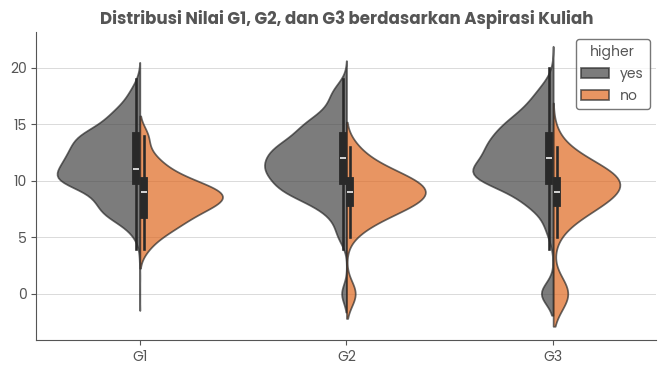

In [ ]:
# Perbandingan nilai antara aspirasi kuliah
df_long = df.melt(id_vars='higher', value_vars=['G1', 'G2', 'G3'], var_name='Nilai', value_name='Skor')

plt.figure(figsize=(8, 4))
sns.violinplot(data=df_long, x='Nilai', y='Skor', hue='higher', split=True, palette=palette[1:3], alpha=0.7)

plt.title("Distribusi Nilai G1, G2, dan G3 berdasarkan Aspirasi Kuliah", fontweight='bold')
plt.xlabel("")
plt.ylabel("")
plt.savefig('higher.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan aspirasi kuliah
result_df = ttest_with_effect_size(df, group_col='higher', group1='yes', group2='no', features=['G1', 'G2', 'G3'], alpha=0.05)
result_df

,Fitur,Rata-rata yes,Rata-rata no,Selisih rata-rata,p-value,Kesimpulan,Effect size (Cohen's d),Interpretasi Effect Size
0,G1,11.460733,8.561798,-2.898935,7.078482e-22,Signifikan,-1.009122,besar
1,G2,11.497382,8.550562,-2.946820,1.538848e-16,Signifikan,-0.926161,besar
2,G3,11.620942,8.348315,-3.272628,3.680265e-13,Signifikan,-0.871101,besar


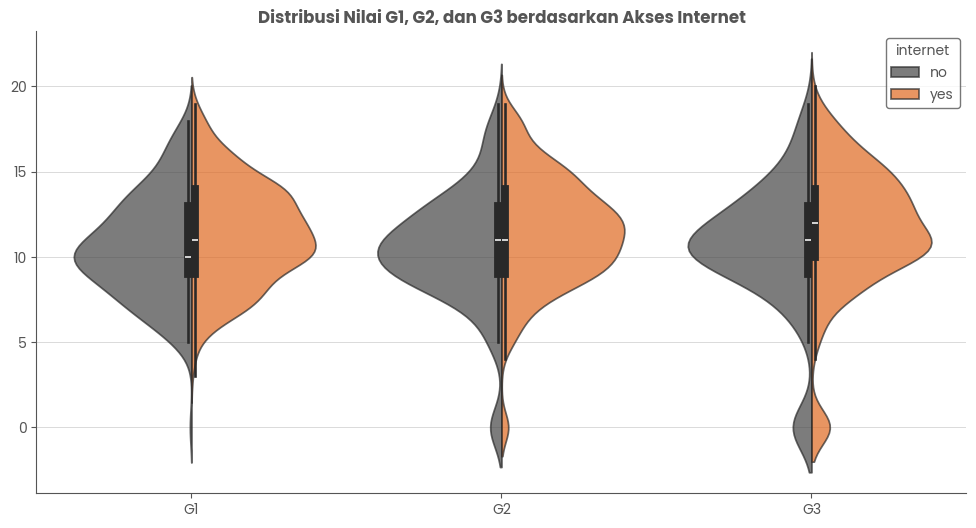

In [ ]:
# Perbandingan nilai antara punya internet atau tidak
df_long = df.melt(id_vars='internet', value_vars=['G1', 'G2', 'G3'], var_name='Nilai', value_name='Skor')

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_long, x='Nilai', y='Skor', hue='internet', split=True, palette=palette[1:3], alpha=0.7)

plt.title("Distribusi Nilai G1, G2, dan G3 berdasarkan Akses Internet", fontweight='bold')
plt.xlabel("")
plt.ylabel("")
plt.savefig('internet.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan punya internet
result_df = ttest_with_effect_size(df, group_col='internet', group1='yes', group2='no', features=['G1', 'G2', 'G3'], alpha=0.05)
result_df

,Fitur,Rata-rata yes,Rata-rata no,Selisih rata-rata,p-value,Kesimpulan,Effect size (Cohen's d),Interpretasi Effect Size
0,G1,11.373640,10.603687,-0.769953,0.000850,Signifikan,-0.259383,kecil
1,G2,11.452237,10.460829,-0.991408,0.000137,Signifikan,-0.303937,kecil
2,G3,11.553809,10.534562,-1.019247,0.000590,Signifikan,-0.265123,kecil


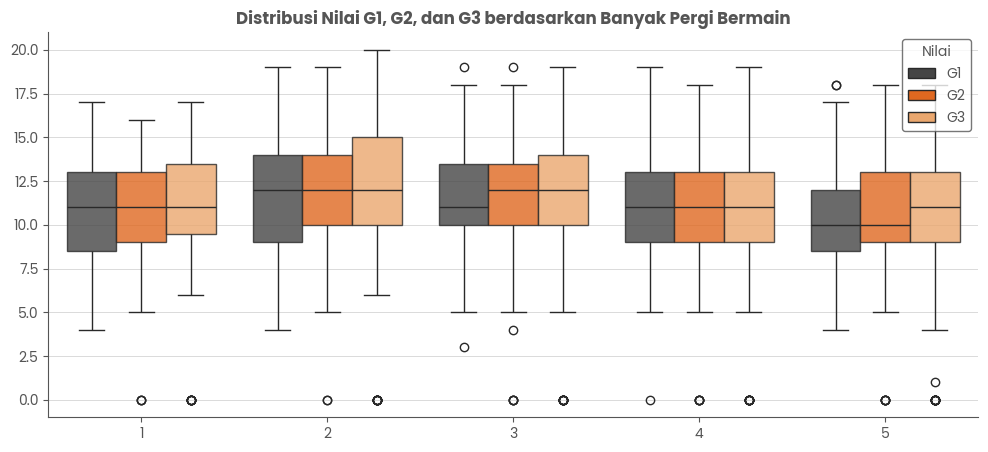

In [ ]:
# Perbandingan nilai antar banyak pergi bermain
df_long = df.melt(id_vars='goout', value_vars=['G1', 'G2', 'G3'], var_name='Nilai', value_name='Skor')

plt.figure(figsize=(12, 5))
ax = sns.boxplot(data=df_long, x='goout', y='Skor', hue='Nilai', palette=palette[1:4])
for patch in ax.patches:
    patch.set_alpha(0.8)
plt.title("Distribusi Nilai G1, G2, dan G3 berdasarkan Banyak Pergi Bermain", fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.savefig('goout.png', transparent=True, dpi=800)
plt.show()

In [ ]:
# Korelasi nilai dengan banyak pergi bermain
result_corr = pearson_corr_with_strength(df, x_col='goout', features=['G1', 'G2', 'G3'], alpha=0.05)
result_corr

,Fitur,Koefisien Korelasi (r),p-value,Kesimpulan,Kekuatan Korelasi
0,G1,-0.101163,0.001063,Signifikan,lemah
1,G2,-0.108411,0.000450,Signifikan,lemah
2,G3,-0.097877,0.001544,Signifikan,sangat lemah


# **4. Preprocessing**

In [13]:
# Memeriksa data kosong
df.isnull().sum().sum()

np.int64(0)

In [14]:
# Memeriksa data kosong
df.duplicated().sum()

np.int64(0)

In [15]:
# Melakukan rekayasa fitur
nom_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'course']
df = pd.get_dummies(df, columns=nom_cols, drop_first=True)

In [16]:
# Memisahkan dataset menjadi data latih dan data uji
X = df.drop(columns=['G3'])
y = df['G3']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

print(X_train.shape)
print(X_test.shape)

(730, 42)
(314, 42)


In [17]:
outlier_info = []
out_cols = [col for col in num_cols if col != 'G3']
col_idx = {col: i for i, col in enumerate(X_train.columns)}

# Inisialisasi mask untuk menandai baris dengan outlier
mask_outlier_train = pd.DataFrame(False, index=X_train.index, columns=out_cols)
mask_outlier_test = pd.DataFrame(False, index=X_test.index, columns=out_cols)

for col in out_cols:
    idx = col_idx[col]
    Q1 = np.percentile(X_train[col], 25)
    Q3 = np.percentile(X_train[col], 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Jumlah dan persen outlier per kolom
    jumlah_outlier_train = ((X_train.iloc[:, idx] < lower_bound) | (X_train.iloc[:, idx] > upper_bound)).sum()
    jumlah_outlier_test = ((X_test.iloc[:, idx] < lower_bound) | (X_test.iloc[:, idx] > upper_bound)).sum()

    persen_outlier_train = jumlah_outlier_train / X_train.shape[0] * 100
    persen_outlier_test = jumlah_outlier_test / X_test.shape[0] * 100

    # Tandai baris-baris yang mengandung outlier
    mask_outlier_train[col] = (X_train.iloc[:, idx] < lower_bound) | (X_train.iloc[:, idx] > upper_bound)
    mask_outlier_test[col] = (X_test.iloc[:, idx] < lower_bound) | (X_test.iloc[:, idx] > upper_bound)

    # Clipping nilai outlier
    X_train[col] = np.clip(X_train[col].astype(float), lower_bound, upper_bound)
    X_test[col] = np.clip(X_test[col].astype(float), lower_bound, upper_bound)

    # Simpan informasi
    outlier_info.append({
        'kolom': col,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'jumlah_outlier_train': jumlah_outlier_train,
        'persen_outlier_train': persen_outlier_train,
        'jumlah_outlier_test': jumlah_outlier_test,
        'persen_outlier_test': persen_outlier_test
    })

# Buat dataframe ringkasan
df_outlier = pd.DataFrame(outlier_info)
display(df_outlier)

# Hitung total baris unik dengan outlier
total_outlier_rows_train = mask_outlier_train.any(axis=1).sum()
total_outlier_rows_test = mask_outlier_test.any(axis=1).sum()

print(f"Jumlah baris unik dengan pencilan di training set: {total_outlier_rows_train}")
print(f"Jumlah baris unik dengan pencilan di test set: {total_outlier_rows_test}")

,kolom,lower_bound,upper_bound,jumlah_outlier_train,persen_outlier_train,jumlah_outlier_test,persen_outlier_test
0,age,13.0,21.0,1,0.136986,1,0.318471
1,Medu,-1.0,7.0,0,0.000000,0,0.000000
2,Fedu,0.5,4.5,6,0.821918,3,0.955414
3,traveltime,-0.5,3.5,15,2.054795,9,2.866242
4,studytime,-0.5,3.5,39,5.342466,23,7.324841
5,failures,0.0,0.0,116,15.890411,67,21.337580
6,famrel,2.5,6.5,51,6.986301,26,8.280255
7,freetime,1.5,5.5,46,6.301370,18,5.732484
8,goout,-1.0,7.0,0,0.000000,0,0.000000
9,Dalc,-0.5,3.5,35,4.794521,17,5.414013


Jumlah baris unik dengan pencilan di training set: 275
Jumlah baris unik dengan pencilan di test set: 139


# **5. Modeling**

In [18]:
# Dictionary model yang mau dicoba
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Linear Regression': LinearRegression(),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
}

# Loop untuk coba semua model
results = {}
for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Hitung metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse
    }

# Buat DataFrame dari hasil
results_df = pd.DataFrame.from_dict(results, orient='index').reset_index()
results_df.rename(columns={'index': 'Model'}, inplace=True)

# Urutkan berdasarkan R² tertinggi
results_df = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)
display(results_df)

,Model,R2,MAE,RMSE
0,Gradient Boosting,0.831268,0.905382,1.582205
1,Random Forest,0.829237,0.918758,1.591699
2,Extra Trees,0.816345,0.970350,1.650691
3,ElasticNet,0.811678,1.000336,1.671533
4,XGBoost,0.809031,0.996032,1.683238
5,Linear Regression,0.805333,1.069276,1.699455
6,KNN (k=5),0.797339,1.070701,1.733999
7,Decision Tree,0.691540,1.257962,2.139260


In [19]:
# Menghitung cv score
best_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
print(f"CV R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

CV R² scores: [0.83400205 0.82782441 0.82642027 0.92089003 0.90807816]
Mean CV R²: 0.8634 (+/- 0.0839)


In [20]:
# Tuning hyperparameter
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt', None],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
print(f"CV R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV score: 0.8698277050209333
CV R² scores: [0.83778391 0.83525929 0.83238821 0.9320033  0.91170381]
Mean CV R²: 0.8698 (+/- 0.0860)


G2                   0.859128
absences             0.057573
G1                   0.052882
course_por           0.006868
goout                0.004729
age                  0.003865
sex_M                0.001979
traveltime           0.001883
Medu                 0.001180
schoolsup_yes        0.001017
health               0.000973
Fjob_other           0.000900
Mjob_teacher         0.000894
reason_home          0.000872
famrel               0.000834
Walc                 0.000693
Fjob_services        0.000602
romantic_yes         0.000589
school_MS            0.000549
Mjob_services        0.000423
paid_yes             0.000419
studytime            0.000359
guardian_mother      0.000236
Dalc                 0.000190
freetime             0.000155
famsup_yes           0.000076
Mjob_other           0.000071
activities_yes       0.000035
famsize_LE3          0.000027
failures             0.000000
Fedu                 0.000000
Mjob_health          0.000000
Pstatus_T            0.000000
address_U 

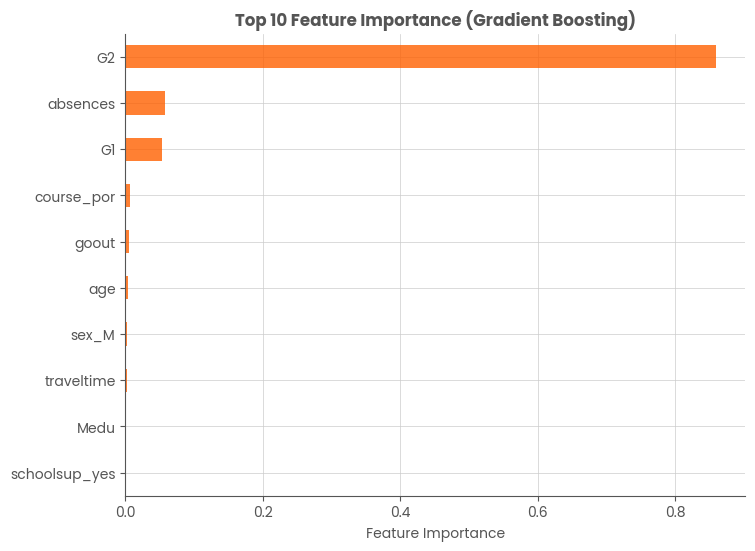

In [21]:
# Feature importance
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
print(feat_imp)

top_n = 10
feat_imp_top = feat_imp.head(top_n)

feat_imp_top.plot(kind='barh', figsize=(8, 6), color=palette[2], alpha=0.8)
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Feature Importance (Gradient Boosting)', fontweight='bold')
plt.gca().invert_yaxis()
plt.savefig('feat_imp.png', transparent=True, dpi=800)
plt.show()

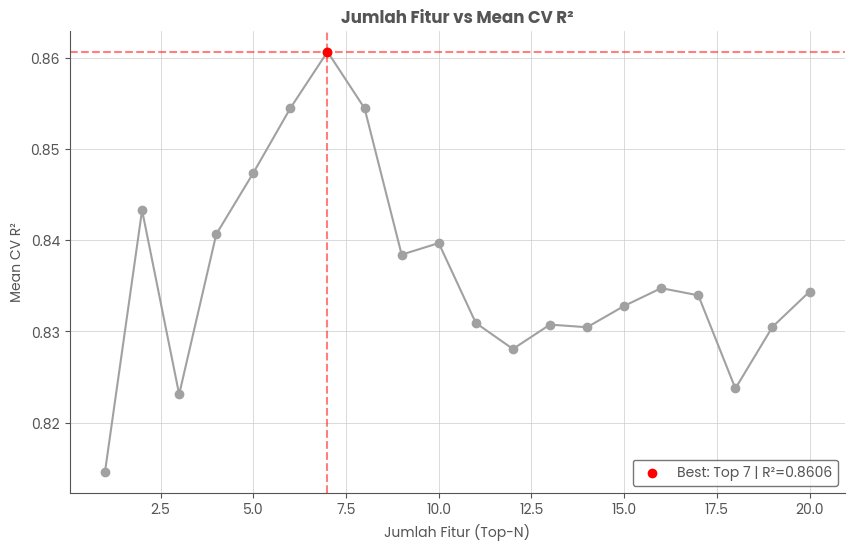

In [22]:
# Optimisasi jumlah fitur
max_n = 20

mean_scores = []
num_features = list(range(1, max_n + 1))

for n in num_features:
    selected = feat_imp.head(n).index.tolist()
    X_sel = X_train[selected]
    score = cross_val_score(model, X_sel, y_train, cv=5, scoring='r2').mean()
    mean_scores.append(score)

mean_scores = np.array(mean_scores)
best_idx = np.argmax(mean_scores)
best_n = num_features[best_idx]
best_score = mean_scores[best_idx]

plt.figure(figsize=(10, 6))
plt.plot(num_features, mean_scores, marker='o', linestyle='-')
plt.scatter(best_n, best_score, color='red', zorder=5, label=f'Best: Top {best_n} | R²={best_score:.4f}')
plt.axhline(y=best_score, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=best_n, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Jumlah Fitur (Top-N)')
plt.ylabel('Mean CV R²')
plt.title('Jumlah Fitur vs Mean CV R²', fontweight='bold')
plt.legend()
plt.grid(True)
plt.savefig('opt_feat.png', transparent=True, dpi=800)
plt.show()

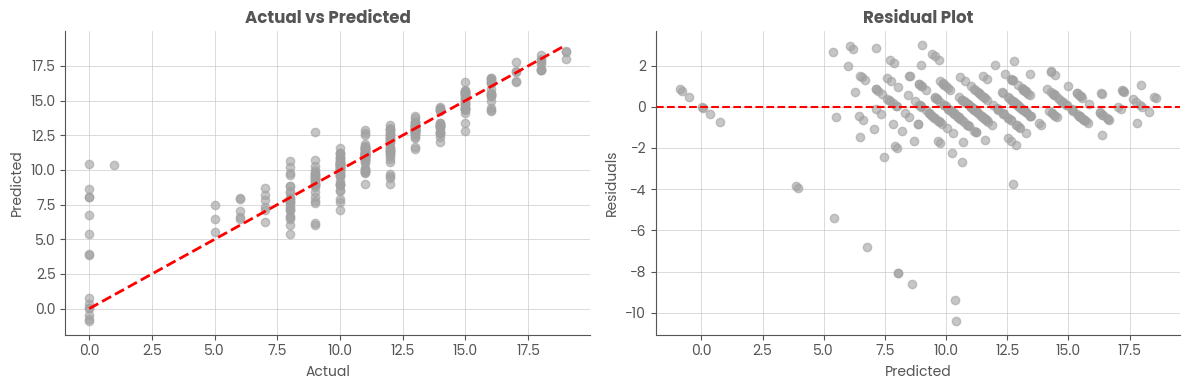

In [23]:
# Residual analysis
residuals = y_test - y_pred

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted', fontweight='bold')

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('residual.png', transparent=True, dpi=800)
plt.show()

Shapiro-Wilk test: statistic=0.7244, p-value=0.0000


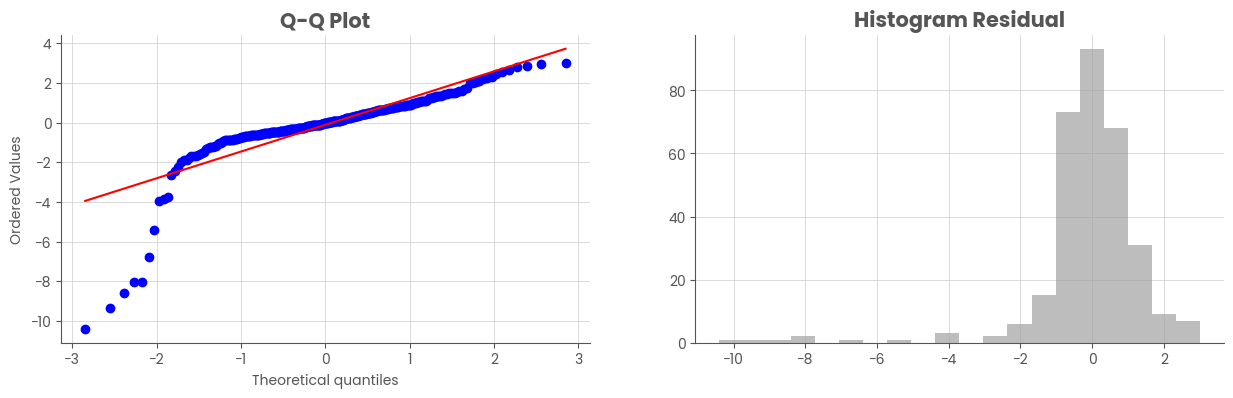

In [24]:
# Uji normalitas residual
shapiro_stat, shapiro_p = shapiro(residuals)
print(f"Shapiro-Wilk test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot', fontweight='bold', fontsize=15)

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=20, alpha=0.7)
plt.title('Histogram Residual', fontweight='bold', fontsize=15)
plt.savefig('residual2.png', transparent=True, dpi=800)
plt.show()

In [31]:
# R², RMSE, dan MAE
def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero_mask = y_true != 0
    if np.any(nonzero_mask):
        return np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    else:
        return np.nan

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = safe_mape(y_test, y_pred)

print("=== MODEL PERFORMANCE METRICS ===")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

=== MODEL PERFORMANCE METRICS ===
R² Score: 0.8346
MAE: 0.8748
RMSE: 1.5667
MAPE: 9.7715


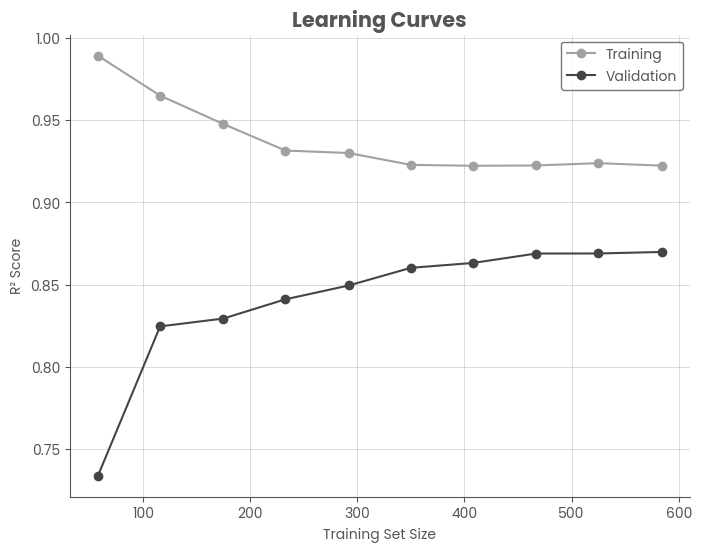

In [26]:
# Learning Curves
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curves', fontweight='bold', fontsize=15)
plt.legend()
plt.savefig('learning_curves.png', transparent=True, dpi=800)
plt.show()

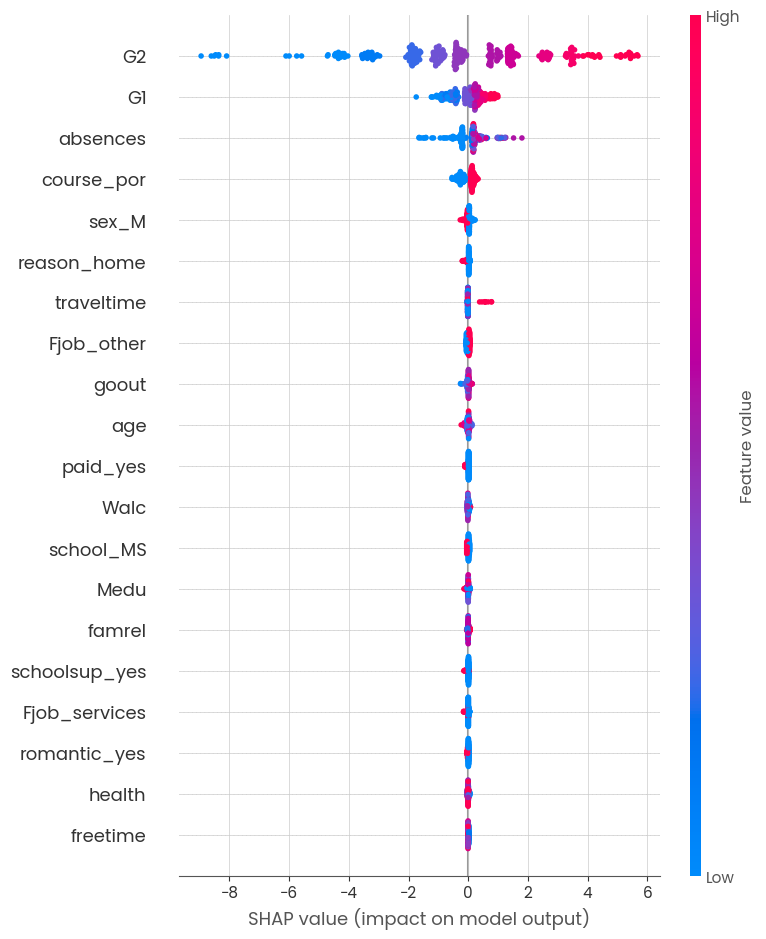

In [27]:
# Model Interpretability (SHAP)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [28]:
# Plot fitur failures
shap.dependence_plot('failures', shap_values, X_test, interaction_index='G2', show=False)
fig = plt.gcf()
fig.set_size_inches(10, 4)
ax = plt.gca()
ax.set_title('Pengaruh Ketidakhadiran terhadap Output Model', fontweight='bold', fontsize=15)
plt.tight_layout()
fig.savefig('dependence_failures.png', transparent=True, dpi=800, bbox_inches='tight')
plt.close(fig)

In [29]:
# Plot fitur higher_yes
shap.dependence_plot('higher_yes', shap_values, X_test, interaction_index='G2', show=False)
fig = plt.gcf()
fig.set_size_inches(10, 4)
ax = plt.gca()
ax.set_title('Pengaruh Ketidakhadiran terhadap Output Model', fontweight='bold', fontsize=15)
plt.tight_layout()
fig.savefig('dependence_higher_yes.png', transparent=True, dpi=800, bbox_inches='tight')
plt.close(fig)

In [33]:
# Plot fitur absences
shap.dependence_plot('absences', shap_values, X_test, interaction_index='G2', show=False)
fig = plt.gcf()
fig.set_size_inches(10, 4)
ax = plt.gca()
ax.set_title('Pengaruh Ketidakhadiran terhadap Output Model', fontweight='bold', fontsize=15)
plt.tight_layout()
fig.savefig('dependence_absences.png', transparent=True, dpi=800, bbox_inches='tight')
plt.close(fig)

In [34]:
# Plot fitur course_por
shap.dependence_plot('course_por', shap_values, X_test, interaction_index='G2', show=False)
fig = plt.gcf()
fig.set_size_inches(9.5, 4)
ax = plt.gca()
ax.set_title('Pengaruh Mata Pelajaran terhadap Output Model', fontweight='bold', fontsize=15)
plt.tight_layout()
fig.savefig('dependence_course_por.png', transparent=True, dpi=800, bbox_inches='tight')
plt.close(fig)

In [35]:
# Plot fitur sex_M
shap.dependence_plot('sex_M', shap_values, X_test, interaction_index='G2', show=False)
fig = plt.gcf()
fig.set_size_inches(9.5, 4)
ax = plt.gca()
ax.set_title('Pengaruh Mata Pelajaran terhadap Output Model', fontweight='bold', fontsize=15)
plt.tight_layout()
fig.savefig('dependence_sex_M.png', transparent=True, dpi=800, bbox_inches='tight')
plt.close(fig)

In [36]:
# Deteksi outlier berdasarkan residual
outlier_threshold = 2.5 * np.std(residuals)
outliers = np.abs(residuals) > outlier_threshold
print(f"Jumlah outliers: {outliers.sum()}")

Jumlah outliers: 7


In [37]:
# Simpan model ke file
joblib.dump(model, 'student_perform_prediction.pkl')
print("Model berhasil disimpan sebagai 'student_perform_prediction.pkl'")

Model berhasil disimpan sebagai 'student_perform_prediction.pkl'
